#Morphology

In [2]:
!pip install rapidfuzz
!pip install fuzzywuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.7 MB/s eta 0:00:00


In [ ]:
!pip install caas-jupyter-tools

ERROR: Could not find a version that satisfies the requirement caas-jupyter-tools (from versions: none)
ERROR: No matching distribution found for caas-jupyter-tools


In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from fuzzywuzzy import process
from IPython.display import display

# === FILE PATHS ===
response_file = "/content/combined_Morph_response_extra_examples_lama3_p1.csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"

# === LOAD DATA ===
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# === PREPROCESS GROUND TRUTH ===
gt_df["MORP"] = gt_df["MORP"].astype(str).str.strip().str.lower().str.replace(r'\s{2,}', ' ', regex=True)
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()

# === EXTRACT JSON FROM RESPONSE ===
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}
    dict_candidates = []
    triple_blocks = re.findall(r'```(?:json)?\s*(.*?)\s*```', text, re.DOTALL | re.IGNORECASE)
    dict_candidates.extend(triple_blocks)
    brace_blocks = re.findall(r'\{.*?\}', text, re.DOTALL)
    dict_candidates.extend(brace_blocks)
    for raw in reversed(dict_candidates):
        dict_str = raw.replace('\\', '').strip()
        try:
            parsed = ast.literal_eval(dict_str)
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            continue
    return {}

resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_morp_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("Morphology", None))

# === NORMALIZATION ===
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    return re.sub(r"\s{2,}", " ", str(label).strip().lower())

gt_df["MORP_NORM"] = gt_df["MORP"].apply(normalize_label)
resp_df["TOPO"] = gt_df["TOPO"]
resp_df["MORP_GT"] = gt_df["MORP_NORM"]

all_morph_labels = sorted(gt_df["MORP_NORM"].unique())

# === MAPPING RULES + FUZZY ===
def match_morp_with_fuzzy(text, label_set):
    try:
        if pd.isnull(text) or str(text).strip() == "":
            return "unknown", 0

        normalized = normalize_label(text)

        if "ductal carcinoma" in normalized:
            return "infiltrating or invasive ductal carcinoma of no special type", 100
        if "mucinous carcinoma" in normalized:
            return "mucinous carcinoma", 100
        if "papillary" in normalized:
            return "papillary carcinoma", 100
        if "acinar" in normalized:
            return "acinar adenocarcinoma", 100
        if "adenocarcinoma" in normalized:
            return "adenocarcinoma of no special type", 100

        match, score = process.extractOne(normalized, label_set)
        if score >= 70:
            return match, score

        return "unknown", score
    except Exception:
        return "unknown", 0

resp_df["match_result"] = resp_df["extracted_morp_raw"].apply(lambda x: match_morp_with_fuzzy(x, all_morph_labels))
resp_df["morp_predicted"] = resp_df["match_result"].apply(lambda x: x[0])

# === BUILD FINAL DATAFRAME FOR REVIEW ===
comparison_df = pd.DataFrame({
    "TOPO": resp_df["TOPO"],
    "Ground Truth (MORP)": gt_df["MORP"],
    "Extracted Morphology (Raw)": resp_df["extracted_morp_raw"],
    "Mapped Prediction": resp_df["morp_predicted"]
})

# === DISPLAY FULL TABLE ===
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(comparison_df)


,TOPO,Ground Truth (MORP),Extracted Morphology (Raw),Mapped Prediction
0,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma (IDC) apocrine variant,infiltrating or invasive ductal carcinoma of no special type
1,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma (NOS),infiltrating or invasive ductal carcinoma of no special type
2,COLORECTAL,adenocarcinoma of no special type,Adenocarcinoma,adenocarcinoma of no special type
3,COLORECTAL,adenocarcinoma of no special type,Moderately differentiated adenocarcinoma,adenocarcinoma of no special type
4,BREAST,mucinous carcinoma,Invasive mucinous carcinoma,mucinous carcinoma
5,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
6,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
7,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
8,BREAST,papillary carcinoma,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
9,BREAST,infiltrating or invasive ductal carcinoma of no special type,"Invasive duct carcinoma, NST, grade III","carcinoma, anaplastic, nos"


In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score
from scipy.stats import f_oneway
from fuzzywuzzy import process
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_Morph_response_extra_examples_lama3_p1.csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# ------------------ Preprocessing ------------------ #
gt_df["MORP"] = gt_df["MORP"].astype(str).str.strip().str.lower().str.replace(r'\s{2,}', ' ', regex=True)
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()

# ------------------ Extract JSON from Response ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}
    dict_candidates = []
    triple_blocks = re.findall(r'```(?:json)?\s*(.*?)\s*```', text, re.DOTALL | re.IGNORECASE)
    dict_candidates.extend(triple_blocks)
    brace_blocks = re.findall(r'\{.*?\}', text, re.DOTALL)
    dict_candidates.extend(brace_blocks)
    for raw in reversed(dict_candidates):
        dict_str = raw.replace('\\', '').strip()
        try:
            parsed = ast.literal_eval(dict_str)
            if isinstance(parsed, dict):
                return parsed
        except:
            continue
    return {}

resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_morp_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("Morphology", None))
resp_df["TOPO"] = gt_df["TOPO"]
resp_df["MORP_GT"] = gt_df["MORP"]

# ------------------ Label Normalization ------------------ #
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    return re.sub(r"\s{2,}", " ", str(label).strip().lower())

gt_df["MORP_NORM"] = gt_df["MORP"].apply(normalize_label)
all_morph_labels = sorted(gt_df["MORP_NORM"].unique())

# ------------------ Improved Mapping Function ------------------ #
def match_morp_with_fuzzy(text, label_set):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    norm = normalize_label(text)

    # High-confidence rule-based mappings
    if "ductal carcinoma" in norm:
        return "infiltrating or invasive ductal carcinoma of no special type", 100
    if "lobular carcinoma" in norm:
        return "infiltrating or invasive lobular carcinoma of no special type", 100
    if "mucinous" in norm:
        return "mucinous carcinoma", 100
    if "papillary" in norm and "thyroid" in norm:
        return "papillary carcinoma", 100
    if "papillary carcinoma" in norm:
        return "papillary carcinoma", 100
    if "acinar" in norm:
        return "acinar adenocarcinoma", 100
    if "follicular" in norm:
        return "follicular carcinoma", 100
    if "adenocarcinoma" in norm:
        return "adenocarcinoma of no special type", 100

    # Fuzzy fallback
    match, score = process.extractOne(norm, label_set)
    if score >= 70:
        return match, score
    return "unknown", score

# ------------------ Apply Matching ------------------ #
resp_df["match_result"] = resp_df["extracted_morp_raw"].apply(lambda x: match_morp_with_fuzzy(x, all_morph_labels))
resp_df["morp_predicted"] = resp_df["match_result"].apply(lambda x: x[0])

# ------------------ Full Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "TOPO": resp_df["TOPO"],
    "Ground Truth (MORP)": gt_df["MORP"],
    "Extracted Morphology (Raw)": resp_df["extracted_morp_raw"],
    "Mapped Prediction": resp_df["morp_predicted"]
})

# Display entire DataFrame
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(comparison_df)

# ------------------ Statistical Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": gt_df["MORP_NORM"],
    "pred": resp_df["morp_predicted"].apply(normalize_label)
})

# Error Categories
unknowns = (combined_df["pred"] == "unknown").sum()
misclassified = (combined_df["true"] != combined_df["pred"]).sum() - unknowns
overpredicted = (~combined_df["pred"].isin(combined_df["true"].unique()) & (combined_df["pred"] != "unknown")).sum()

total = len(combined_df)
error_profile = {
    "Overprediction %": round((overpredicted / total) * 100, 2),
    "Misclassification %": round((misclassified / total) * 100, 2),
    "Unknown %": round((unknowns / total) * 100, 2)
}

# Bootstrapped F1 Score
f1_scores = []
np.random.seed(42)
for _ in range(100):
    sample = combined_df.sample(frac=0.7, replace=False)
    f1 = f1_score(sample["true"], sample["pred"], average="weighted", zero_division=0)
    f1_scores.append(f1)

ci_lower = np.percentile(f1_scores, 2.5)
ci_upper = np.percentile(f1_scores, 97.5)
mean_f1 = np.mean(f1_scores)
anova_p = f_oneway(f1_scores, f1_scores).pvalue

# ------------------ Display Summary ------------------ #
print("\n📊 Evaluation Summary:")
print(f"Mean Weighted F1: {mean_f1:.4f}")
print(f"95% Confidence Interval: ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"ANOVA p-value: {anova_p:.4f}")
print("Error Profile (%):", error_profile)


,TOPO,Ground Truth (MORP),Extracted Morphology (Raw),Mapped Prediction
0,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma (IDC) apocrine variant,infiltrating or invasive ductal carcinoma of no special type
1,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma (NOS),infiltrating or invasive ductal carcinoma of no special type
2,COLORECTAL,adenocarcinoma of no special type,Adenocarcinoma,adenocarcinoma of no special type
3,COLORECTAL,adenocarcinoma of no special type,Moderately differentiated adenocarcinoma,adenocarcinoma of no special type
4,BREAST,mucinous carcinoma,Invasive mucinous carcinoma,mucinous carcinoma
5,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
6,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
7,BREAST,infiltrating or invasive ductal carcinoma of no special type,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
8,BREAST,papillary carcinoma,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
9,BREAST,infiltrating or invasive ductal carcinoma of no special type,"Invasive duct carcinoma, NST, grade III","carcinoma, anaplastic, nos"



📊 Evaluation Summary:
Mean Weighted F1: 0.6243
95% Confidence Interval: (0.6012, 0.6497)
ANOVA p-value: 1.0000
Error Profile (%): {'Overprediction %': np.float64(0.0), 'Misclassification %': np.float64(35.08), 'Unknown %': np.float64(5.41)}


In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.stats import f_oneway
from fuzzywuzzy import process
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_Morph_response_extra_examples_lama3_p1.csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# ------------------ Preprocessing ------------------ #
gt_df["MORP"] = (
    gt_df["MORP"].astype(str).str.strip().str.lower().str.replace(r'\s{2,}', ' ', regex=True)
)
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()

# ------------------ SELECT THYROID ONLY ------------------ #
gt_df = gt_df[gt_df["TOPO"] == "THYROID"].reset_index(drop=True)
resp_df = resp_df.loc[gt_df.index].reset_index(drop=True)

# ------------------ Extract JSON from Response ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}
    dict_candidates = []
    triple_blocks = re.findall(
        r'```(?:json)?\s*(.*?)\s*```',
        text, re.DOTALL | re.IGNORECASE
    )
    dict_candidates.extend(triple_blocks)
    brace_blocks = re.findall(r"\{.*?\}", text, re.DOTALL)
    dict_candidates.extend(brace_blocks)
    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip())
            if isinstance(parsed, dict):
                return parsed
        except:
            continue
    return {}

resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_morp_raw"] = resp_df["parsed_dict"].apply(
    lambda d: d.get("Morphology", None)
)

# ------------------ Label Normalization ------------------ #
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    return re.sub(r"\s{2,}", " ", str(label).strip().lower())

gt_df["MORP_NORM"] = gt_df["MORP"].apply(normalize_label)
all_morph_labels = sorted(gt_df["MORP_NORM"].unique())

# ------------------ Improved Mapping ------------------ #
def match_morp_with_fuzzy(text, label_set):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    norm = normalize_label(text)

    # High-confidence rule-based mappings
    if "ductal carcinoma" in norm:
        return "infiltrating or invasive ductal carcinoma of no special type", 100
    if "lobular carcinoma" in norm:
        return "infiltrating or invasive lobular carcinoma of no special type", 100
    if "mucinous" in norm:
        return "mucinous carcinoma", 100
    if "papillary" in norm and "thyroid" in norm:
        return "papillary carcinoma", 100
    if "papillary carcinoma" in norm:
        return "papillary carcinoma", 100
    if "acinar" in norm:
        return "acinar adenocarcinoma", 100
    if "follicular" in norm:
        return "follicular carcinoma", 100
    if "adenocarcinoma" in norm:
        return "adenocarcinoma of no special type", 100

    # Fuzzy fallback
    match, score = process.extractOne(norm, label_set)
    if score >= 70:
        return match, score
    return "unknown", score

# ------------------ Apply Mapping ------------------ #
resp_df["match_result"] = resp_df["extracted_morp_raw"].apply(
    lambda x: match_morp_with_fuzzy(x, all_morph_labels)
)
resp_df["morp_predicted"] = resp_df["match_result"].apply(lambda x: x[0])

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "TOPO": gt_df["TOPO"],
    "Ground Truth (MORP)": gt_df["MORP"],
    "Extracted Morphology (Raw)": resp_df["extracted_morp_raw"],
    "Mapped Prediction": resp_df["morp_predicted"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
display(comparison_df)

# ------------------ Statistical Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": gt_df["MORP_NORM"],
    "pred": resp_df["morp_predicted"].apply(normalize_label)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# Error Profile
unknowns = (y_pred == "unknown").sum()
misclassified = (y_pred != y_true).sum() - unknowns
overpredicted = (
    ~y_pred.isin(y_true.unique()) & (y_pred != "unknown")
).sum()

total = len(combined_df)
error_profile = {
    "Overprediction %": round((overpredicted / total) * 100, 2),
    "Misclassification %": round((misclassified / total) * 100, 2),
    "Unknown %": round((unknowns / total) * 100, 2),
}

# Bootstrapping
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]

    weighted_f1_list.append(
        f1_score(yt, yp, average="weighted", zero_division=0)
    )
    macro_f1_list.append(
        f1_score(yt, yp, average="macro", zero_division=0)
    )
    macro_precision_list.append(
        precision_score(yt, yp, average="macro", zero_division=0)
    )
    macro_recall_list.append(
        recall_score(yt, yp, average="macro", zero_division=0)
    )

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (THYROID ONLY)")
print("====================================")
print(f"Macro Precision:  {np.mean(macro_precision_list):.4f}")
print(f"Macro Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)


,TOPO,Ground Truth (MORP),Extracted Morphology (Raw),Mapped Prediction
0,THYROID,follicular carcinoma,Invasive ductal carcinoma (IDC) apocrine variant,infiltrating or invasive ductal carcinoma of no special type
1,THYROID,papillary carcinoma,Invasive ductal carcinoma (NOS),infiltrating or invasive ductal carcinoma of no special type
2,THYROID,"carcinoma, anaplastic, nos",Adenocarcinoma,adenocarcinoma of no special type
3,THYROID,papillary carcinoma,Moderately differentiated adenocarcinoma,adenocarcinoma of no special type
4,THYROID,follicular carcinoma,Invasive mucinous carcinoma,mucinous carcinoma
5,THYROID,papillary carcinoma,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
6,THYROID,papillary carcinoma,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
7,THYROID,papillary carcinoma,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
8,THYROID,papillary carcinoma,Invasive ductal carcinoma,infiltrating or invasive ductal carcinoma of no special type
9,THYROID,papillary carcinoma,"Invasive duct carcinoma, NST, grade III","carcinoma, anaplastic, nos"



📊 EVALUATION SUMMARY (THYROID ONLY)
Macro Precision:  0.0590
Macro Recall:     0.0015
Macro F1:         0.0029  (95% CI: 0.0000, 0.0118)
Weighted F1:      0.0212  (95% CI: 0.0000, 0.0889)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(74.73), 'Misclassification %': np.float64(87.91), 'Unknown %': np.float64(10.99)}


##lama-p1

In [27]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from scipy.stats import ttest_rel
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_Morph_response_extra_examples_lama3_p1.csv"
baseline_file = "/content/regex_morph_review_colorectal.csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)
baseline_df = pd.read_csv(baseline_file)

# ------------------ Helper Functions ------------------ #
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    label = str(label).strip().lower()
    label = re.sub(r"\s+", " ", label)
    if label in ["", "nan", "none", "null"]:
        return "unknown"
    return label

def extract_latest_dict(text):
    if pd.isnull(text):
        return {}

    dict_candidates = []

    triple_blocks = re.findall(
        r"```(?:json)?\s*(.*?)\s*```",
        str(text),
        re.DOTALL | re.IGNORECASE
    )
    dict_candidates.extend(triple_blocks)

    brace_blocks = re.findall(r"\{.*?\}", str(text), re.DOTALL)
    dict_candidates.extend(brace_blocks)

    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip())
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            continue

    return {}

# ------------------ Preprocessing ------------------ #
gt_df["mrn"] = gt_df["mrn"].astype(str).str.strip()
resp_df["mrn"] = resp_df["mrn"].astype(str).str.strip()
baseline_df["mrn"] = baseline_df["mrn"].astype(str).str.strip()

gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()
baseline_df["TOPO"] = baseline_df["TOPO"].astype(str).str.strip().str.upper()

gt_df["MORP"] = (
    gt_df["MORP"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s{2,}", " ", regex=True)
)

# ------------------ Filter to COLORECTAL ------------------ #
site = "COLORECTAL"

gt_df = gt_df[gt_df["TOPO"] == site].copy()
baseline_df = baseline_df[baseline_df["TOPO"] == site].copy()

# Keep only shared MRNs across all three files
shared_mrns = (
    set(gt_df["mrn"])
    & set(resp_df["mrn"])
    & set(baseline_df["mrn"])
)

gt_df = gt_df[gt_df["mrn"].isin(shared_mrns)].copy()
resp_df = resp_df[resp_df["mrn"].isin(shared_mrns)].copy()
baseline_df = baseline_df[baseline_df["mrn"].isin(shared_mrns)].copy()

# ------------------ Normalize Ground Truth ------------------ #
gt_df["MORP_NORM"] = gt_df["MORP"].apply(normalize_label)
all_morph_labels = sorted(gt_df["MORP_NORM"].unique())

# ------------------ Extract LLM Morphology ------------------ #
resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_morp_raw"] = resp_df["parsed_dict"].apply(
    lambda d: d.get("Morphology", None)
)

# ------------------ Map LLM Prediction ------------------ #
def match_morp_with_fuzzy(text, label_set):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    norm = normalize_label(text)

    # High-confidence mappings
    if "ductal carcinoma" in norm:
        return "infiltrating or invasive ductal carcinoma of no special type", 100

    if "lobular carcinoma" in norm:
        return "infiltrating or invasive lobular carcinoma of no special type", 100

    if "mucinous" in norm:
        return "mucinous carcinoma", 100

    if "papillary" in norm and "thyroid" in norm:
        return "papillary carcinoma", 100

    if "papillary carcinoma" in norm:
        return "papillary carcinoma", 100

    if "acinar" in norm:
        return "acinar adenocarcinoma", 100

    if "follicular" in norm:
        return "follicular carcinoma", 100

    if "adenocarcinoma" in norm:
        return "adenocarcinoma of no special type", 100

    # Fuzzy fallback
    match, score = process.extractOne(norm, label_set)

    if score >= 70:
        return match, score

    return "unknown", score

resp_df["match_result"] = resp_df["extracted_morp_raw"].apply(
    lambda x: match_morp_with_fuzzy(x, all_morph_labels)
)

resp_df["morp_predicted"] = (
    resp_df["match_result"]
    .apply(lambda x: x[0])
    .apply(normalize_label)
)

# ------------------ Baseline Prediction ------------------ #
baseline_pred_col = "MORP_PRED_MAPPED"

baseline_df["morp_baseline_predicted"] = (
    baseline_df[baseline_pred_col]
    .apply(normalize_label)
)

# ------------------ Merge by MRN ------------------ #
merged_df = (
    gt_df[["mrn", "TOPO", "MORP", "MORP_NORM"]]
    .merge(
        resp_df[["mrn", "extracted_morp_raw", "morp_predicted"]],
        on="mrn",
        how="inner"
    )
    .merge(
        baseline_df[["mrn", "morp_baseline_predicted"]],
        on="mrn",
        how="inner"
    )
)

print("Merged shape:", merged_df.shape)

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "mrn": merged_df["mrn"],
    "TOPO": merged_df["TOPO"],
    "Ground Truth (MORP)": merged_df["MORP_NORM"],
    "Extracted Morphology (Raw)": merged_df["extracted_morp_raw"],
    "Mapped LLM Prediction": merged_df["morp_predicted"],
    "Mapped Baseline Prediction": merged_df["morp_baseline_predicted"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(comparison_df)

# ------------------ Evaluation DataFrame ------------------ #
combined_df = pd.DataFrame({
    "true": merged_df["MORP_NORM"].astype(str),
    "pred": merged_df["morp_predicted"].astype(str),
    "baseline_pred": merged_df["morp_baseline_predicted"].astype(str)
})

# ------------------ Error Profile: LLM ------------------ #
y_true = combined_df["true"]
y_pred = combined_df["pred"]

unknowns = (y_pred == "unknown").sum()
misclassified = (y_pred != y_true).sum() - unknowns
overpredicted = (
    ~y_pred.isin(y_true.unique()) &
    (y_pred != "unknown")
).sum()

total = len(combined_df)

error_profile = {
    "Overprediction %": round((overpredicted / total) * 100, 2),
    "Misclassification %": round((misclassified / total) * 100, 2),
    "Unknown %": round((unknowns / total) * 100, 2)
}

# ------------------ Bootstrapped Metrics + Paired t-test ------------------ #
N = 100

weighted_f1_list = []
macro_f1_list = []
weighted_precision_list = []
weighted_recall_list = []
baseline_weighted_f1_list = []

rng = np.random.default_rng(42)

n = len(combined_df)
sample_size = int(n * 0.7)

for _ in range(N):
    indices = rng.choice(n, size=sample_size, replace=True)

    sample = combined_df.iloc[indices]

    yt = sample["true"]
    yp = sample["pred"]
    yb = sample["baseline_pred"]

    weighted_f1_list.append(
        f1_score(yt, yp, average="weighted", zero_division=0)
    )

    macro_f1_list.append(
        f1_score(yt, yp, average="macro", zero_division=0)
    )

    weighted_precision_list.append(
        precision_score(yt, yp, average="weighted", zero_division=0)
    )

    weighted_recall_list.append(
        recall_score(yt, yp, average="weighted", zero_division=0)
    )

    baseline_weighted_f1_list.append(
        f1_score(yt, yb, average="weighted", zero_division=0)
    )

# Paired t-test: LLM vs baseline
t_stat, p_value = ttest_rel(weighted_f1_list, baseline_weighted_f1_list)

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (COLORECTAL MORPHOLOGY)")
print("==============================================")

print(f"Weighted Precision (LLM):  {np.mean(weighted_precision_list):.4f}")
print(f"Weighted Recall (LLM):     {np.mean(weighted_recall_list):.4f}")

print(
    f"Macro F1 (LLM):            {np.mean(macro_f1_list):.4f} "
    f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, "
    f"{np.percentile(macro_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (LLM):         {np.mean(weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(weighted_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (Baseline):    {np.mean(baseline_weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(baseline_weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(baseline_weighted_f1_list, 97.5):.4f})"
)

if p_value < 0.001:
    print("Paired t-test p-value:     p < 0.001")
else:
    print(f"Paired t-test p-value:     {p_value:.6f}")

print("\nError Profile (LLM %, O/M/H):", error_profile)

/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Merged shape: (100, 7)


,mrn,TOPO,Ground Truth (MORP),Extracted Morphology (Raw),Mapped LLM Prediction,Mapped Baseline Prediction
0,1279594,COLORECTAL,adenocarcinoma of no special type,Adenocarcinoma,adenocarcinoma of no special type,unknown
1,1389006,COLORECTAL,adenocarcinoma of no special type,Moderately differentiated adenocarcinoma,adenocarcinoma of no special type,infiltrating or invasive lobular carcinoma of no special type
2,1363852,COLORECTAL,adenocarcinoma of no special type,"Adenocarcinoma, NOS",adenocarcinoma of no special type,unknown
3,1223997,COLORECTAL,adenocarcinoma of no special type,Invasive moderately differentiated adenocarcinoma,adenocarcinoma of no special type,infiltrating or invasive ductal carcinoma of no special type
4,183374,COLORECTAL,adenocarcinoma of no special type,Moderately differentiated adenocarcinoma,adenocarcinoma of no special type,unknown
5,1234081,COLORECTAL,adenocarcinoma of no special type,Invasive moderately differentiated adenocarcinoma,adenocarcinoma of no special type,unknown
6,1296072,COLORECTAL,adenocarcinoma of no special type,Rectal adenocarcinoma,adenocarcinoma of no special type,mucinous adenocarcinoma
7,1376822,COLORECTAL,adenocarcinoma of no special type,pT3 well differentiated adenocarcinoma,adenocarcinoma of no special type,unknown
8,1285928,COLORECTAL,adenocarcinoma of no special type,"Adenocarcinoma, NOS",adenocarcinoma of no special type,unknown
9,1362399,COLORECTAL,adenocarcinoma of no special type,Adenocarcinoma,adenocarcinoma of no special type,unknown



📊 EVALUATION SUMMARY (COLORECTAL MORPHOLOGY)
Weighted Precision (LLM):  0.9068
Weighted Recall (LLM):     0.8577
Macro F1 (LLM):            0.2170 (95% CI: 0.1790, 0.3172)
Weighted F1 (LLM):         0.8811 (95% CI: 0.8222, 0.9493)
Weighted F1 (Baseline):    0.0391 (95% CI: 0.0000, 0.0902)
Paired t-test p-value:     p < 0.001

Error Profile (LLM %, O/M/H): {'Overprediction %': np.float64(4.0), 'Misclassification %': np.float64(7.0), 'Unknown %': np.float64(7.0)}


In [ ]:
import pandas as pd

# Load
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)
baseline_df = pd.read_csv(baseline_file)

# Print column names
print("GT columns:")
print(gt_df.columns.tolist())

print("\nResponse columns:")
print(resp_df.columns.tolist())

print("\nBaseline columns:")
print(baseline_df.columns.tolist())

GT columns:
['mrn', 'TOPO', 'MORP', 'GRADE', 'T', 'N', 'M', 'STAGE', 'LATER', 'TRE-1']

Response columns:
['mrn', 'prompt_type', 'response']

Baseline columns:
['mrn', 'TOPO', 'MORP', 'MORP_GT_NORM', 'MORP (pred)', 'MORP_PRED_NORM', 'MORP_PRED_MAPPED', 'MORP_MATCH_SCORE']


##lama-p2

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from scipy.stats import ttest_rel
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_Morph_response_extra_examples_lama3_p1.csv"
baseline_file = "/content/regex_morph_review_colorectal.csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.csv"  # update if needed

# ------------------ Load Data ------------------ #
gt_df = pd.read_csv(gt_file)
resp_df = pd.read_csv(response_file)
baseline_df = pd.read_csv(baseline_file)

# ------------------ Preprocessing ------------------ #
gt_df["mrn"] = gt_df["mrn"].astype(str).str.strip()
resp_df["mrn"] = resp_df["mrn"].astype(str).str.strip()
baseline_df["mrn"] = baseline_df["mrn"].astype(str).str.strip()

gt_df["MORP"] = (
    gt_df["MORP"].astype(str).str.strip().str.lower().str.replace(r"\s{2,}", " ", regex=True)
)
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()
baseline_df["TOPO"] = baseline_df["TOPO"].astype(str).str.strip().str.upper()

# ------------------ Filter to COLORECTAL ------------------ #
gt_df = gt_df[gt_df["TOPO"] == "COLORECTAL"].copy()
baseline_df = baseline_df[baseline_df["TOPO"] == "COLORECTAL"].copy()

# Keep only cases present in baseline file
gt_df = gt_df[gt_df["mrn"].isin(baseline_df["mrn"])].copy()
resp_df = resp_df[resp_df["mrn"].isin(baseline_df["mrn"])].copy()

# ------------------ Extract JSON from LLM Response ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}
    dict_candidates = []
    triple_blocks = re.findall(r"```(?:json)?\s*(.*?)\s*```", str(text), re.DOTALL | re.IGNORECASE)
    dict_candidates.extend(triple_blocks)
    brace_blocks = re.findall(r"\{.*?\}", str(text), re.DOTALL)
    dict_candidates.extend(brace_blocks)
    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip())
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            continue
    return {}

resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_morp_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("Morphology", None))

# ------------------ Label Normalization ------------------ #
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    label = str(label).strip().lower()
    label = re.sub(r"\s{2,}", " ", label)
    if label in ["", "nan", "none", "null"]:
        return "unknown"
    return label

gt_df["MORP_NORM"] = gt_df["MORP"].apply(normalize_label)
all_morph_labels = sorted(gt_df["MORP_NORM"].unique())

# ------------------ Mapping for LLM predictions ------------------ #
def match_morp_with_fuzzy(text, label_set):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    norm = normalize_label(text)

    if "ductal carcinoma" in norm:
        return "infiltrating or invasive ductal carcinoma of no special type", 100
    if "lobular carcinoma" in norm:
        return "infiltrating or invasive lobular carcinoma of no special type", 100
    if "mucinous" in norm:
        return "mucinous carcinoma", 100
    if "papillary" in norm and "thyroid" in norm:
        return "papillary carcinoma", 100
    if "papillary carcinoma" in norm:
        return "papillary carcinoma", 100
    if "acinar" in norm:
        return "acinar adenocarcinoma", 100
    if "follicular" in norm:
        return "follicular carcinoma", 100
    if "adenocarcinoma" in norm:
        return "adenocarcinoma of no special type", 100

    match, score = process.extractOne(norm, label_set)
    if score >= 70:
        return match, score
    return "unknown", score

resp_df["match_result"] = resp_df["extracted_morp_raw"].apply(
    lambda x: match_morp_with_fuzzy(x, all_morph_labels)
)
resp_df["morp_predicted"] = resp_df["match_result"].apply(lambda x: x[0]).apply(normalize_label)

# ------------------ Prepare baseline ------------------ #
baseline_df["morp_baseline_predicted"] = baseline_df["MORP_PRED_MAPPED"].apply(normalize_label)

# ------------------ Merge all on mrn ------------------ #
merged_df = gt_df[["mrn", "TOPO", "MORP", "MORP_NORM"]].merge(
    resp_df[["mrn", "extracted_morp_raw", "morp_predicted"]],
    on="mrn",
    how="inner"
).merge(
    baseline_df[["mrn", "morp_baseline_predicted"]],
    on="mrn",
    how="inner"
)

print("Merged shape:", merged_df.shape)

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "mrn": merged_df["mrn"],
    "TOPO": merged_df["TOPO"],
    "Ground Truth (MORP)": merged_df["MORP_NORM"],
    "Extracted Morphology (Raw)": merged_df["extracted_morp_raw"],
    "Mapped LLM Prediction": merged_df["morp_predicted"],
    "Mapped Baseline Prediction": merged_df["morp_baseline_predicted"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
display(comparison_df)

# ------------------ Evaluation Data ------------------ #
combined_df = pd.DataFrame({
    "true": merged_df["MORP_NORM"].astype(str),
    "pred": merged_df["morp_predicted"].astype(str),
    "baseline_pred": merged_df["morp_baseline_predicted"].astype(str)
})

# ------------------ Error Profile: LLM ------------------ #
y_true = combined_df["true"]
y_pred = combined_df["pred"]

unknowns = (y_pred == "unknown").sum()
misclassified = (y_pred != y_true).sum() - unknowns
overpredicted = (~y_pred.isin(y_true.unique()) & (y_pred != "unknown")).sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round((overpredicted / total) * 100, 2),
    "Misclassification %": round((misclassified / total) * 100, 2),
    "Unknown %": round((unknowns / total) * 100, 2),
}

# ------------------ Bootstrapped Metrics + Paired t-test ------------------ #
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []
baseline_weighted_f1_list = []

rng = np.random.default_rng(42)
n = len(combined_df)
sample_size = int(n * 0.7)

for _ in range(N):
    indices = rng.choice(n, size=sample_size, replace=True)

    sample = combined_df.iloc[indices]
    yt = sample["true"]
    yp = sample["pred"]
    yb = sample["baseline_pred"]

    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))
    baseline_weighted_f1_list.append(f1_score(yt, yb, average="weighted", zero_division=0))

t_stat, p_value = ttest_rel(weighted_f1_list, baseline_weighted_f1_list)

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (COLORECTAL MORPHOLOGY)")
print("==============================================")
print(f"Weighted Precision (LLM):  {np.mean(macro_precision_list):.4f}")
print(f"Weighted Recall (LLM):     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1 (LLM):            {np.mean(macro_f1_list):.4f} "
      f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1 (LLM):         {np.mean(weighted_f1_list):.4f} "
      f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print(f"Weighted F1 (Baseline):    {np.mean(baseline_weighted_f1_list):.4f} "
      f"(95% CI: {np.percentile(baseline_weighted_f1_list, 2.5):.4f}, {np.percentile(baseline_weighted_f1_list, 97.5):.4f})")
print(f"Paired t-test p-value:     {p_value:.6f}")
print("\nError Profile (LLM %, O/M/H):", error_profile)

Merged shape: (100, 7)


,mrn,TOPO,Ground Truth (MORP),Extracted Morphology (Raw),Mapped LLM Prediction,Mapped Baseline Prediction
0,1279594,COLORECTAL,adenocarcinoma of no special type,Adenocarcinoma,adenocarcinoma of no special type,unknown
1,1389006,COLORECTAL,adenocarcinoma of no special type,Moderately differentiated adenocarcinoma,adenocarcinoma of no special type,infiltrating or invasive lobular carcinoma of no special type
2,1363852,COLORECTAL,adenocarcinoma of no special type,"Adenocarcinoma, NOS",adenocarcinoma of no special type,unknown
3,1223997,COLORECTAL,adenocarcinoma of no special type,Invasive moderately differentiated adenocarcinoma,adenocarcinoma of no special type,infiltrating or invasive ductal carcinoma of no special type
4,183374,COLORECTAL,adenocarcinoma of no special type,Moderately differentiated adenocarcinoma,adenocarcinoma of no special type,unknown
5,1234081,COLORECTAL,adenocarcinoma of no special type,Invasive moderately differentiated adenocarcinoma,adenocarcinoma of no special type,unknown
6,1296072,COLORECTAL,adenocarcinoma of no special type,Rectal adenocarcinoma,adenocarcinoma of no special type,mucinous adenocarcinoma
7,1376822,COLORECTAL,adenocarcinoma of no special type,pT3 well differentiated adenocarcinoma,adenocarcinoma of no special type,unknown
8,1285928,COLORECTAL,adenocarcinoma of no special type,"Adenocarcinoma, NOS",adenocarcinoma of no special type,unknown
9,1362399,COLORECTAL,adenocarcinoma of no special type,Adenocarcinoma,adenocarcinoma of no special type,unknown



📊 EVALUATION SUMMARY (COLORECTAL MORPHOLOGY)
Weighted Precision (LLM):  0.9068
Weighted Recall (LLM):     0.8577
Macro F1 (LLM):            0.2170 (95% CI: 0.1790, 0.3172)
Weighted F1 (LLM):         0.8811 (95% CI: 0.8222, 0.9493)
Weighted F1 (Baseline):    0.0391 (95% CI: 0.0000, 0.0902)
Paired t-test p-value:     0.000000

Error Profile (LLM %, O/M/H): {'Overprediction %': np.float64(4.0), 'Misclassification %': np.float64(7.0), 'Unknown %': np.float64(7.0)}


In [ ]:
baseline_df.columns

Index(['mrn', 'TOPO', 'MORP', 'MORP_GT_NORM', 'MORP (pred)', 'MORP_PRED_NORM',
       'MORP_PRED_MAPPED', 'MORP_MATCH_SCORE', 'baseline_match_result',
       'morp_baseline_predicted'],
      dtype='object')

##lama-p3

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_Morph_response_extra_examples_lama3_p3 (1).csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples (2).xlsx"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# ------------------ Preprocessing ------------------ #
gt_df["MORP"] = (
    gt_df["MORP"].astype(str).str.strip().str.lower().str.replace(r'\s{2,}', ' ', regex=True)
)
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()

# ------------------ Filter TOPO == "THYROID" ------------------ #
thyroid_mask = gt_df["TOPO"] == "THYROID"
gt_df = gt_df[thyroid_mask].reset_index(drop=True)
resp_df = resp_df.loc[thyroid_mask].reset_index(drop=True)

# ------------------ Extract JSON from Response ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}
    dict_candidates = []
    triple_blocks = re.findall(r'```(?:json)?\s*(.*?)\s*```', text, re.DOTALL | re.IGNORECASE)
    dict_candidates.extend(triple_blocks)
    brace_blocks = re.findall(r"\{.*?\}", text, re.DOTALL)
    dict_candidates.extend(brace_blocks)
    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip())
            if isinstance(parsed, dict):
                return parsed
        except:
            continue
    return {}

resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_morp_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("Morphology", None))

# ------------------ Label Normalization ------------------ #
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    return re.sub(r"\s{2,}", " ", str(label).strip().lower())

gt_df["MORP_NORM"] = gt_df["MORP"].apply(normalize_label)
all_morph_labels = sorted(gt_df["MORP_NORM"].unique())

# ------------------ Improved Mapping ------------------ #
def match_morp_with_fuzzy(text, label_set):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0
    norm = normalize_label(text)
    # Rule-based high confidence mappings
    if "ductal carcinoma" in norm:
        return "infiltrating or invasive ductal carcinoma of no special type", 100
    if "lobular carcinoma" in norm:
        return "infiltrating or invasive lobular carcinoma of no special type", 100
    if "mucinous" in norm:
        return "mucinous carcinoma", 100
    if "papillary" in norm and "thyroid" in norm:
        return "papillary carcinoma", 100
    if "papillary carcinoma" in norm:
        return "papillary carcinoma", 100
    if "acinar" in norm:
        return "acinar adenocarcinoma", 100
    if "follicular" in norm:
        return "follicular carcinoma", 100
    if "adenocarcinoma" in norm:
        return "adenocarcinoma of no special type", 100
    # Fuzzy fallback
    match, score = process.extractOne(norm, label_set)
    if score >= 70:
        return match, score
    return "unknown", score

# ------------------ Apply Mapping ------------------ #
resp_df["match_result"] = resp_df["extracted_morp_raw"].apply(
    lambda x: match_morp_with_fuzzy(x, all_morph_labels)
)
resp_df["morp_predicted"] = resp_df["match_result"].apply(lambda x: x[0])

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "TOPO": gt_df["TOPO"],
    "Ground Truth (MORP)": gt_df["MORP"],
    "Extracted Morphology (Raw)": resp_df["extracted_morp_raw"],
    "Mapped Prediction": resp_df["morp_predicted"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
display(comparison_df)

# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": gt_df["MORP_NORM"],
    "pred": resp_df["morp_predicted"].apply(normalize_label)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# Error Profile
unknowns = (y_pred == "unknown").sum()
misclassified = (y_pred != y_true).sum() - unknowns
overpredicted = (
    ~y_pred.isin(y_true.unique()) & (y_pred != "unknown")
).sum()
total = len(combined_df)
error_profile = {
    "Overprediction %": round((overpredicted / total) * 100, 2),
    "Misclassification %": round((misclassified / total) * 100, 2),
    "Unknown %": round((unknowns / total) * 100, 2),
}

# Bootstrapped Metrics
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (THYROID RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)


,TOPO,Ground Truth (MORP),Extracted Morphology (Raw),Mapped Prediction
0,THYROID,follicular carcinoma,Follicular thyroid cancer with metastasis to bone,follicular carcinoma
1,THYROID,papillary carcinoma,Papillary thyroid carcinoma,papillary carcinoma
2,THYROID,"carcinoma, anaplastic, nos","Carcinoma, NOS","carcinoma, anaplastic, nos"
3,THYROID,papillary carcinoma,Papillary thyroid cancer with metastasis to the brain,papillary carcinoma
4,THYROID,follicular carcinoma,"Follicular adenocarcinoma, NOS",follicular carcinoma
5,THYROID,papillary carcinoma,"Adenocarcinoma, NOS",adenocarcinoma of no special type
6,THYROID,papillary carcinoma,Papillary carcinoma (follicular variant) with multiple encapsulated papillary microcarcinomas,papillary carcinoma
7,THYROID,papillary carcinoma,"Carcinoma, NOS","carcinoma, anaplastic, nos"
8,THYROID,papillary carcinoma,Papillary Thyroid Cancer,papillary carcinoma
9,THYROID,papillary carcinoma,Papillary carcinoma,papillary carcinoma



📊 EVALUATION SUMMARY (THYROID RECORDS ONLY)
weighted Precision:  0.9479
weighted Recall:     0.3175
Macro F1:         0.2753  (95% CI: 0.1322, 0.3981)
Weighted F1:      0.4219  (95% CI: 0.2960, 0.5706)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(5.49), 'Misclassification %': np.float64(51.65), 'Unknown %': np.float64(15.38)}


##lama-p4

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_Morph_response_extra_examples_lama3_p4 (1).csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples (2).xlsx"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# ------------------ Preprocessing ------------------ #
gt_df["MORP"] = (
    gt_df["MORP"].astype(str).str.strip().str.lower().str.replace(r'\s{2,}', ' ', regex=True)
)
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()

# ------------------ Filter TOPO == "THYROID" ------------------ #
thyroid_mask = gt_df["TOPO"] == "THYROID"
gt_df = gt_df[thyroid_mask].reset_index(drop=True)
resp_df = resp_df.loc[thyroid_mask].reset_index(drop=True)

# ------------------ Extract JSON from Response ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}
    dict_candidates = []
    triple_blocks = re.findall(r'```(?:json)?\s*(.*?)\s*```', text, re.DOTALL | re.IGNORECASE)
    dict_candidates.extend(triple_blocks)
    brace_blocks = re.findall(r"\{.*?\}", text, re.DOTALL)
    dict_candidates.extend(brace_blocks)
    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip())
            if isinstance(parsed, dict):
                return parsed
        except:
            continue
    return {}

resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_morp_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("Morphology", None))

# ------------------ Label Normalization ------------------ #
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    return re.sub(r"\s{2,}", " ", str(label).strip().lower())

gt_df["MORP_NORM"] = gt_df["MORP"].apply(normalize_label)
all_morph_labels = sorted(gt_df["MORP_NORM"].unique())

# ------------------ Improved Mapping ------------------ #
def match_morp_with_fuzzy(text, label_set):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0
    norm = normalize_label(text)
    # Rule-based high confidence mappings
    if "ductal carcinoma" in norm:
        return "infiltrating or invasive ductal carcinoma of no special type", 100
    if "lobular carcinoma" in norm:
        return "infiltrating or invasive lobular carcinoma of no special type", 100
    if "mucinous" in norm:
        return "mucinous carcinoma", 100
    if "papillary" in norm and "thyroid" in norm:
        return "papillary carcinoma", 100
    if "papillary carcinoma" in norm:
        return "papillary carcinoma", 100
    if "acinar" in norm:
        return "acinar adenocarcinoma", 100
    if "follicular" in norm:
        return "follicular carcinoma", 100
    if "adenocarcinoma" in norm:
        return "adenocarcinoma of no special type", 100
    # Fuzzy fallback
    match, score = process.extractOne(norm, label_set)
    if score >= 70:
        return match, score
    return "unknown", score

# ------------------ Apply Mapping ------------------ #
resp_df["match_result"] = resp_df["extracted_morp_raw"].apply(
    lambda x: match_morp_with_fuzzy(x, all_morph_labels)
)
resp_df["morp_predicted"] = resp_df["match_result"].apply(lambda x: x[0])

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "TOPO": gt_df["TOPO"],
    "Ground Truth (MORP)": gt_df["MORP"],
    "Extracted Morphology (Raw)": resp_df["extracted_morp_raw"],
    "Mapped Prediction": resp_df["morp_predicted"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
display(comparison_df)

# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": gt_df["MORP_NORM"],
    "pred": resp_df["morp_predicted"].apply(normalize_label)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# Error Profile
unknowns = (y_pred == "unknown").sum()
misclassified = (y_pred != y_true).sum() - unknowns
overpredicted = (
    ~y_pred.isin(y_true.unique()) & (y_pred != "unknown")
).sum()
total = len(combined_df)
error_profile = {
    "Overprediction %": round((overpredicted / total) * 100, 2),
    "Misclassification %": round((misclassified / total) * 100, 2),
    "Unknown %": round((unknowns / total) * 100, 2),
}

# Bootstrapped Metrics
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (THYROID RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)


,TOPO,Ground Truth (MORP),Extracted Morphology (Raw),Mapped Prediction
0,THYROID,follicular carcinoma,Follicular thyroid cancer with metastasis to bone,follicular carcinoma
1,THYROID,papillary carcinoma,Papillary thyroid carcinoma,papillary carcinoma
2,THYROID,"carcinoma, anaplastic, nos",Anaplastic Carcinoma,"carcinoma, anaplastic, nos"
3,THYROID,papillary carcinoma,Papillary thyroid cancer with metastasis to the brain,papillary carcinoma
4,THYROID,follicular carcinoma,"Follicular adenocarcinoma, NOS",follicular carcinoma
5,THYROID,papillary carcinoma,Papillary thyroid carcinoma,papillary carcinoma
6,THYROID,papillary carcinoma,Papillary carcinoma (follicular variant) with multiple encapsulated papillary microcarcinomas,papillary carcinoma
7,THYROID,papillary carcinoma,"Carcinoma, NOS","carcinoma, anaplastic, nos"
8,THYROID,papillary carcinoma,Papillary Thyroid Cancer,papillary carcinoma
9,THYROID,papillary carcinoma,Papillary carcinoma,papillary carcinoma



📊 EVALUATION SUMMARY (THYROID RECORDS ONLY)
weighted Precision:  0.9454
weighted Recall:     0.5962
Macro F1:         0.3269  (95% CI: 0.2151, 0.4630)
Weighted F1:      0.7013  (95% CI: 0.5823, 0.8028)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(9.89), 'Misclassification %': np.float64(34.07), 'Unknown %': np.float64(5.49)}


#Grade

##deepseek -p1

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from scipy.stats import ttest_rel
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_Grade_response_extra_examples_deepseek_p1.csv"
baseline_file = "/content/regex_grade_review_thyroid.csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)
baseline_df = pd.read_csv(baseline_file)

# ------------------ Site-Specific Grade Labels ------------------ #
site_labels = {
    "BREAST": [
        "grade 1 or grade i; also called well-differentiated",
        "grade 2 or grade ii; also called moderately differentiated",
        "grade 3 or grade iii; also called poorly differentiated",
        "unknown"
    ],
    "COLORECTAL": [
        "grade 1 or grade i; also called well-differentiated",
        "grade 2 or grade ii; also called moderately differentiated",
        "grade 3 or grade iii; also called poorly differentiated",
        "unknown"
    ],
    "THYROID": [
        "grade 1 or grade i; also called well-differentiated",
        "grade 2 or grade ii; also called moderately differentiated",
        "grade 3 or grade iii; also called poorly differentiated",
        "unknown"
    ],
    "PROSTATE": [
        "group 1 (gleason score 3 + 3 = 6)",
        "group 2 (gleason score 3 + 4 = 7)",
        "group 4 (gleason score 4 + 4 = 8)",
        "group 5 (gleason score 5 + 4 = 9)",
        "unknown"
    ]
}

manual_grade_map = {
    "i": "grade 1 or grade i; also called well-differentiated",
    "1": "grade 1 or grade i; also called well-differentiated",
    "ii": "grade 2 or grade ii; also called moderately differentiated",
    "2": "grade 2 or grade ii; also called moderately differentiated",
    "iii": "grade 3 or grade iii; also called poorly differentiated",
    "3": "grade 3 or grade iii; also called poorly differentiated",
    "grade1": "grade 1 or grade i; also called well-differentiated",
    "grade2": "grade 2 or grade ii; also called moderately differentiated",
    "grade3": "grade 3 or grade iii; also called poorly differentiated",
    "g1": "grade 1 or grade i; also called well-differentiated",
    "g2": "grade 2 or grade ii; also called moderately differentiated",
    "g3": "grade 3 or grade iii; also called poorly differentiated",
    "gleasonscore3+3=6": "group 1 (gleason score 3 + 3 = 6)",
    "gleasonscore3+4=7": "group 2 (gleason score 3 + 4 = 7)",
    "gleasonscore4+4=8": "group 4 (gleason score 4 + 4 = 8)",
    "gleasonscore5+4=9": "group 5 (gleason score 5 + 4 = 9)",
    "6": "group 1 (gleason score 3 + 3 = 6)",
    "7": "group 2 (gleason score 3 + 4 = 7)",
    "8": "group 4 (gleason score 4 + 4 = 8)",
    "9": "group 5 (gleason score 5 + 4 = 9)"
}

# ------------------ Utility Functions ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}

    dict_candidates = []
    triple_blocks = re.findall(
        r"```(?:json)?\s*(.*?)\s*```",
        str(text),
        re.DOTALL | re.IGNORECASE
    )
    brace_blocks = re.findall(r"\{.*?\}", str(text), re.DOTALL)
    dict_candidates.extend(triple_blocks + brace_blocks)

    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip().replace("\\", ""))
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            continue

    return {}

def normalize_label(label):
    if pd.isnull(label):
        return "unknown"

    label = str(label).strip().lower()
    label = re.sub(r"\s+", " ", label)

    if label in ["", "nan", "none", "null"]:
        return "unknown"

    return label

def match_grade_with_manual_and_fuzzy(text, topo, threshold=70):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    if topo not in site_labels:
        return "unknown", 0

    cleaned = normalize_label(text).replace(" ", "")

    if cleaned in manual_grade_map:
        mapped = manual_grade_map[cleaned]
        if mapped in site_labels[topo]:
            return mapped, 100

    match, score = process.extractOne(normalize_label(text), site_labels[topo])

    if score >= threshold:
        return match, score

    return "unknown", score

# ------------------ Normalize IDs and labels ------------------ #
gt_df["mrn"] = gt_df["mrn"].astype(str).str.strip()
resp_df["mrn"] = resp_df["mrn"].astype(str).str.strip()
baseline_df["mrn"] = baseline_df["mrn"].astype(str).str.strip()

gt_df["GRADE"] = gt_df["GRADE"].astype(str).str.strip().str.lower()
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()
baseline_df["TOPO"] = baseline_df["TOPO"].astype(str).str.strip().str.upper()

# ------------------ Filter to THYROID ------------------ #
site = "THYROID"

gt_df = gt_df[gt_df["TOPO"] == site].copy()
baseline_df = baseline_df[baseline_df["TOPO"] == site].copy()

# Keep only shared MRNs across all three files
shared_mrns = set(gt_df["mrn"]) & set(resp_df["mrn"]) & set(baseline_df["mrn"])

gt_df = gt_df[gt_df["mrn"].isin(shared_mrns)].copy()
resp_df = resp_df[resp_df["mrn"].isin(shared_mrns)].copy()
baseline_df = baseline_df[baseline_df["mrn"].isin(shared_mrns)].copy()

print("GT thyroid cases:", len(gt_df))
print("Response matched cases:", len(resp_df))
print("Baseline matched cases:", len(baseline_df))

# ------------------ Extract and Normalize LLM output ------------------ #
resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_grade_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("Grade", None))

gt_df["GRADE_NORM"] = gt_df["GRADE"].apply(normalize_label)

# Add TOPO to response for mapping
resp_df = resp_df.merge(
    gt_df[["mrn", "TOPO"]],
    on="mrn",
    how="left"
)

resp_df["match_result"] = resp_df.apply(
    lambda row: match_grade_with_manual_and_fuzzy(row["extracted_grade_raw"], row["TOPO"]),
    axis=1
)

resp_df["grade_predicted"] = (
    resp_df["match_result"]
    .apply(lambda x: x[0])
    .apply(normalize_label)
)

# ------------------ Baseline predictions ------------------ #
print("Baseline columns:")
print(baseline_df.columns.tolist())

baseline_pred_col = "GRADE_PRED_MAPPED"

if baseline_pred_col not in baseline_df.columns:
    raise KeyError(
        f"Column '{baseline_pred_col}' not found in baseline file. "
        f"Available columns are: {baseline_df.columns.tolist()}"
    )

baseline_df["grade_baseline_predicted"] = (
    baseline_df[baseline_pred_col]
    .apply(normalize_label)
)

# ------------------ Merge all on mrn ------------------ #
merged_df = (
    gt_df[["mrn", "TOPO", "GRADE", "GRADE_NORM"]]
    .merge(
        resp_df[["mrn", "extracted_grade_raw", "grade_predicted"]],
        on="mrn",
        how="inner"
    )
    .merge(
        baseline_df[["mrn", "grade_baseline_predicted"]],
        on="mrn",
        how="inner"
    )
)

print("Merged shape:", merged_df.shape)

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "mrn": merged_df["mrn"],
    "TOPO": merged_df["TOPO"],
    "Ground Truth (GRADE)": merged_df["GRADE_NORM"],
    "Extracted Grade (Raw)": merged_df["extracted_grade_raw"],
    "Mapped LLM Prediction": merged_df["grade_predicted"],
    "Mapped Baseline Prediction": merged_df["grade_baseline_predicted"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(comparison_df)

# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": merged_df["GRADE_NORM"].astype(str),
    "pred": merged_df["grade_predicted"].astype(str),
    "baseline_pred": merged_df["grade_baseline_predicted"].astype(str)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# ------------------ Error Profile: LLM ------------------ #
unknowns = (y_pred == "unknown").sum()
valid_mask = y_pred != "unknown"
misclassified = (y_pred[valid_mask] != y_true[valid_mask]).sum()
overpredicted = (
    ~y_pred.isin(y_true.unique()) &
    (y_pred != "unknown")
).sum()

total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / valid_mask.sum() * 100, 2) if valid_mask.sum() > 0 else 0,
    "Unknown %": round(unknowns / total * 100, 2)
}

# ------------------ Bootstrapped Metrics + Paired t-test ------------------ #
N = 100

weighted_f1_list = []
macro_f1_list = []
weighted_precision_list = []
weighted_recall_list = []
baseline_weighted_f1_list = []

rng = np.random.default_rng(42)

n = len(combined_df)
sample_size = int(n * 0.7)

for _ in range(N):
    indices = rng.choice(n, size=sample_size, replace=True)

    sample = combined_df.iloc[indices]

    yt = sample["true"]
    yp = sample["pred"]
    yb = sample["baseline_pred"]

    weighted_f1_list.append(
        f1_score(yt, yp, average="weighted", zero_division=0)
    )

    macro_f1_list.append(
        f1_score(yt, yp, average="macro", zero_division=0)
    )

    weighted_precision_list.append(
        precision_score(yt, yp, average="weighted", zero_division=0)
    )

    weighted_recall_list.append(
        recall_score(yt, yp, average="weighted", zero_division=0)
    )

    baseline_weighted_f1_list.append(
        f1_score(yt, yb, average="weighted", zero_division=0)
    )

# Paired t-test
t_stat, p_value = ttest_rel(weighted_f1_list, baseline_weighted_f1_list)

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (THYROID GRADE)")
print("==============================================")

print(f"Weighted Precision (LLM):  {np.mean(weighted_precision_list):.4f}")
print(f"Weighted Recall (LLM):     {np.mean(weighted_recall_list):.4f}")

print(
    f"Macro F1 (LLM):            {np.mean(macro_f1_list):.4f} "
    f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, "
    f"{np.percentile(macro_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (LLM):         {np.mean(weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(weighted_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (Baseline):    {np.mean(baseline_weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(baseline_weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(baseline_weighted_f1_list, 97.5):.4f})"
)

if p_value < 0.001:
    print("Paired t-test p-value:     p < 0.001")
else:
    print(f"Paired t-test p-value:     {p_value:.6f}")

print("\nError Profile (LLM %, O/M/H):", error_profile)

GT thyroid cases: 91
Response matched cases: 91
Baseline matched cases: 86
Baseline columns:
['mrn', 'TOPO', 'GRADE', 'GRADE_GT_MAPPED', 'GRADE (pred)', 'GRADE_PRED_MAPPED', 'GRADE_MATCH_SCORE']
Merged shape: (121, 7)


,mrn,TOPO,Ground Truth (GRADE),Extracted Grade (Raw),Mapped LLM Prediction,Mapped Baseline Prediction
0,1266302,THYROID,unknown,,unknown,grade 1 or grade i; also called well-differentiated
1,1266302,THYROID,unknown,,unknown,grade 1 or grade i; also called well-differentiated
2,1266302,THYROID,unknown,IV,unknown,grade 1 or grade i; also called well-differentiated
3,1266302,THYROID,unknown,IV,unknown,grade 1 or grade i; also called well-differentiated
4,1270724,THYROID,unknown,Not specified,unknown,unknown
5,1270724,THYROID,unknown,Not specified,unknown,unknown
6,1270724,THYROID,unknown,,unknown,unknown
7,1270724,THYROID,unknown,,unknown,unknown
8,1237716,THYROID,unknown,Anaplastic,unknown,unknown
9,1237716,THYROID,unknown,Anaplastic,unknown,unknown



📊 EVALUATION SUMMARY (THYROID GRADE)
Weighted Precision (LLM):  0.8951
Weighted Recall (LLM):     0.8990
Macro F1 (LLM):            0.2077 (95% CI: 0.1880, 0.2477)
Weighted F1 (LLM):         0.8969 (95% CI: 0.8288, 0.9555)
Weighted F1 (Baseline):    0.7844 (95% CI: 0.6976, 0.8638)
Paired t-test p-value:     p < 0.001

Error Profile (LLM %, O/M/H): {'Overprediction %': np.float64(6.61), 'Misclassification %': np.float64(100.0), 'Unknown %': np.float64(93.39)}


##lama-p4

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process

# ------------------ File Paths ------------------ #
response_file = "/content/combined_Grade_response_extra_examples_lama3_p4 (1).csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples (2).xlsx"

# ------------------ Site-Specific Grade Labels ------------------ #
site_labels = {
    "BREAST": [
        "grade 1 or grade i; also called well-differentiated",
        "grade 2 or grade ii; also called moderately differentiated",
        "grade 3 or grade iii; also called poorly differentiated",
        "unknown"
    ],
    "COLORECTAL": [
        "grade 1 or grade i; also called well-differentiated",
        "grade 2 or grade ii; also called moderately differentiated",
        "grade 3 or grade iii; also called poorly differentiated",
        "unknown"
    ],
    "THYROID": [
        "grade 1 or grade i; also called well-differentiated",
        "grade 2 or grade ii; also called moderately differentiated",
        "grade 3 or grade iii; also called poorly differentiated",
        "unknown"
    ],
    "PROSTATE": [
        "group 1 (gleason score 3 + 3 = 6)",
        "group 2 (gleason score 3 + 4 = 7)",
        "group 4 (gleason score 4 + 4 = 8)",
        "group 5 (gleason score 5 + 4 = 9)",
        "unknown"
    ]
}

# ------------------ Manual Map ------------------ #
manual_grade_map = {
    "i": "grade 1 or grade i; also called well-differentiated",
    "1": "grade 1 or grade i; also called well-differentiated",
    "ii": "grade 2 or grade ii; also called moderately differentiated",
    "2": "grade 2 or grade ii; also called moderately differentiated",
    "iii": "grade 3 or grade iii; also called poorly differentiated",
    "3": "grade 3 or grade iii; also called poorly differentiated",
    "grade1": "grade 1 or grade i; also called well-differentiated",
    "grade2": "grade 2 or grade ii; also called moderately differentiated",
    "grade3": "grade 3 or grade iii; also called poorly differentiated",
    "g1": "grade 1 or grade i; also called well-differentiated",
    "g2": "grade 2 or grade ii; also called moderately differentiated",
    "g3": "grade 3 or grade iii; also called poorly differentiated",
    "gleasonscore3+3=6": "group 1 (gleason score 3 + 3 = 6)",
    "gleasonscore3+4=7": "group 2 (gleason score 3 + 4 = 7)",
    "gleasonscore4+4=8": "group 4 (gleason score 4 + 4 = 8)",
    "gleasonscore5+4=9": "group 5 (gleason score 5 + 4 = 9)",
    "6": "group 1 (gleason score 3 + 3 = 6)",
    "7": "group 2 (gleason score 3 + 4 = 7)",
    "8": "group 4 (gleason score 4 + 4 = 8)",
    "9": "group 5 (gleason score 5 + 4 = 9)"
}

# ------------------ Utility Functions ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text): return {}
    dict_candidates = []
    triple_blocks = re.findall(r'```(?:json)?\s*(.*?)\s*```', str(text), re.DOTALL | re.IGNORECASE)
    brace_blocks = re.findall(r'\{.*?\}', str(text), re.DOTALL)
    dict_candidates.extend(triple_blocks + brace_blocks)
    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip().replace("\\", ""))
            if isinstance(parsed, dict):
                return parsed
        except:
            continue
    return {}

def normalize_label(label):
    if pd.isnull(label): return "unknown"
    return re.sub(r"\s+", " ", str(label).strip().lower())

def match_grade_with_manual_and_fuzzy(text, topo, threshold=70):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0
    if topo not in site_labels:
        return "unknown", 0

    cleaned = normalize_label(text).replace(" ", "")
    if cleaned in manual_grade_map:
        mapped = manual_grade_map[cleaned]
        if mapped in site_labels[topo]:
            return mapped, 100

    match, score = process.extractOne(normalize_label(text), site_labels[topo])
    if score >= threshold:
        return match, score

    return "unknown", score

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# Normalize GT
gt_df["GRADE"] = gt_df["GRADE"].astype(str).str.strip().str.lower()
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()

# Filter to THYROID
thyroid_idx = gt_df.index[gt_df["TOPO"] == "THYROID"]
gt_df = gt_df.loc[thyroid_idx].reset_index(drop=True)
resp_df = resp_df.loc[thyroid_idx].reset_index(drop=True)

resp_df["TOPO"] = gt_df["TOPO"]

# ------------------ Extract and Normalize ------------------ #
resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["extracted_grade_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("Grade", None))

gt_df["GRADE_NORM"] = gt_df["GRADE"].apply(normalize_label)

resp_df["match_result"] = resp_df.apply(
    lambda row: match_grade_with_manual_and_fuzzy(row["extracted_grade_raw"], row["TOPO"]),
    axis=1
)
resp_df["grade_predicted"] = resp_df["match_result"].apply(lambda x: x[0])

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "TOPO": gt_df["TOPO"],
    "Ground Truth (GRADE)": gt_df["GRADE"],
    "Extracted Grade (Raw)": resp_df["extracted_grade_raw"],
    "Mapped Prediction": resp_df["grade_predicted"]
})
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
display(comparison_df)
# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": gt_df["GRADE_NORM"],
    "pred": resp_df["grade_predicted"].apply(normalize_label)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

unknowns = (y_pred == "unknown").sum()
valid_mask = y_pred != "unknown"
misclassified = (y_pred[valid_mask] != y_true[valid_mask]).sum()
overpredicted = (~y_pred.isin(y_true.unique()) & (y_pred != "unknown")).sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / valid_mask.sum() * 100, 2) if valid_mask.sum() > 0 else 0,
    "Unknown %": round(unknowns / total * 100, 2)
}

# ------------------ Bootstrapping ------------------ #

# Bootstrapped Metrics
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (THYROID RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)


,TOPO,Ground Truth (GRADE),Extracted Grade (Raw),Mapped Prediction
0,THYROID,unknown,High,unknown
1,THYROID,unknown,T3N1M1,unknown
2,THYROID,unknown,Anaplastic,unknown
3,THYROID,unknown,Well-differentiated (assuming typical for papillary thyroid cancer),unknown
4,THYROID,not applicable,Well differentiated,grade 1 or grade i; also called well-differentiated
5,THYROID,unknown,Not mentioned,unknown
6,THYROID,unknown,pT2NxMx,unknown
7,THYROID,unknown,,unknown
8,THYROID,unknown,IV,unknown
9,THYROID,unknown,CKD-5,unknown



📊 EVALUATION SUMMARY (THYROID RECORDS ONLY)
weighted Precision:  0.9780
weighted Recall:     0.9250
Macro F1:         0.2579  (95% CI: 0.1603, 0.4961)
Weighted F1:      0.9505  (95% CI: 0.9007, 0.9921)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(7.69), 'Misclassification %': np.float64(100.0), 'Unknown %': np.float64(92.31)}


#T category

##lama-p3

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process

# ------------------ File Paths ------------------ #
response_file = "/content/combined_tnm_response_extra_examples_lama3_p3 (1).csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples (2).xlsx"

# ------------------ Utility Functions ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text): return {}
    dict_candidates = []
    triple_blocks = re.findall(r'```(?:json)?\s*(.*?)\s*```', str(text), re.DOTALL | re.IGNORECASE)
    brace_blocks = re.findall(r'\{.*?\}', str(text), re.DOTALL)
    dict_candidates.extend(triple_blocks + brace_blocks)
    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip().replace("\\", ""))
            if isinstance(parsed, dict):
                return parsed
        except:
            continue
    return {}

t_labels = ["t1", "t2", "t3", "t4", "tis", "unknown"]

def normalize_t_value(text):
    if not isinstance(text, str):
        return "unknown"
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9]', '', text)

    if text.startswith("pt"):
        text = text[2:]
    elif text.startswith("p"):
        text = text[1:]

    if text in ["t1", "t1a", "t1b", "t1c", "pt1a", "pt1b", "pt1c"]:
        return "t1"
    elif text == "t2":
        return "t2"
    elif text in ["t3", "pt3m"]:
        return "t3"
    elif text in ["t4", "t4a", "t4b", "t4c", "t4d"]:
        return "t4"
    elif text in ["tis", "ptis"]:
        return "tis"
    else:
        match, score = process.extractOne(text, t_labels)
        return match if score >= 80 else "unknown"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# Normalize GT
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()
gt_df["T"] = gt_df["T"].apply(normalize_t_value)

# Filter for TOPO == "THYROID"
thyroid_idx = gt_df.index[gt_df["TOPO"] == "THYROID"]
gt_df = gt_df.loc[thyroid_idx].reset_index(drop=True)
resp_df = resp_df.loc[thyroid_idx].reset_index(drop=True)

# ------------------ Extract and Normalize ------------------ #
resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["T_pred_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("T", None))
resp_df["T_pred_norm"] = resp_df["T_pred_raw"].apply(normalize_t_value)
# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "TOPO": gt_df["TOPO"],
    "Ground Truth (T)": gt_df["T"],
    "Extracted Grade (Raw)": resp_df["T_pred_raw"],
    "Mapped Prediction": resp_df["T_pred_norm"]
})
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
display(comparison_df)
# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": gt_df["T"],
    "pred": resp_df["T_pred_norm"]
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

unknowns = (y_pred == "unknown").sum()
valid_mask = y_pred != "unknown"
misclassified = (y_pred[valid_mask] != y_true[valid_mask]).sum()
overpredicted = (~y_pred.isin(y_true.unique()) & (y_pred != "unknown")).sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / valid_mask.sum() * 100, 2) if valid_mask.sum() > 0 else 0,
    "Unknown %": round(unknowns / total * 100, 2)
}

# Bootstrapped Metrics
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (THYROID RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)

,TOPO,Ground Truth (T),Extracted Grade (Raw),Mapped Prediction
0,THYROID,unknown,4,t4
1,THYROID,t3,T3,t3
2,THYROID,unknown,T4,t4
3,THYROID,unknown,T4,t4
4,THYROID,unknown,T2,t2
5,THYROID,t3,T3,t3
6,THYROID,t2,T2,t2
7,THYROID,unknown,Tx,unknown
8,THYROID,t4,T4,t4
9,THYROID,unknown,Papillary Carcinoma,unknown



📊 EVALUATION SUMMARY (THYROID RECORDS ONLY)
weighted Precision:  0.8622
weighted Recall:     0.7595
Macro F1:         0.6261  (95% CI: 0.4895, 0.7480)
Weighted F1:      0.7887  (95% CI: 0.6884, 0.8826)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(0.0), 'Misclassification %': np.float64(47.5), 'Unknown %': np.float64(56.04)}


##lama-p4

In [28]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from scipy.stats import ttest_rel
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_tnm_response_extra_examples_lama3_p4.csv"
baseline_file = "/content/regex_T_review_thyroid.csv"   # update if needed
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"

# ------------------ Utility Functions ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}

    dict_candidates = []
    triple_blocks = re.findall(
        r'```(?:json)?\s*(.*?)\s*```',
        str(text),
        re.DOTALL | re.IGNORECASE
    )
    brace_blocks = re.findall(r'\{.*?\}', str(text), re.DOTALL)
    dict_candidates.extend(triple_blocks + brace_blocks)

    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip().replace("\\", ""))
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            continue

    return {}

t_labels = ["t1", "t2", "t3", "t4", "tis", "unknown"]

def normalize_t_value(text):
    if pd.isnull(text):
        return "unknown"

    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9]", "", text)

    if text in ["", "nan", "none", "null", "unknown"]:
        return "unknown"

    if text.startswith("pt"):
        text = text[2:]
    elif text.startswith("p"):
        text = text[1:]

    if text in ["t1", "t1a", "t1b", "t1c"]:
        return "t1"
    elif text == "t2":
        return "t2"
    elif text in ["t3", "t3a", "t3b", "pt3m"]:
        return "t3"
    elif text in ["t4", "t4a", "t4b", "t4c", "t4d"]:
        return "t4"
    elif text == "tis":
        return "tis"
    else:
        match, score = process.extractOne(text, t_labels)
        return match if score >= 80 else "unknown"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)
baseline_df = pd.read_csv(baseline_file)

# ------------------ Normalize IDs ------------------ #
gt_df["mrn"] = gt_df["mrn"].astype(str).str.strip()
resp_df["mrn"] = resp_df["mrn"].astype(str).str.strip()
baseline_df["mrn"] = baseline_df["mrn"].astype(str).str.strip()

# ------------------ Normalize GT ------------------ #
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()
baseline_df["TOPO"] = baseline_df["TOPO"].astype(str).str.strip().str.upper()

gt_df["T_NORM"] = gt_df["T"].apply(normalize_t_value)

# ------------------ Filter to THYROID ------------------ #
site = "THYROID"

gt_df = gt_df[gt_df["TOPO"] == site].copy()
baseline_df = baseline_df[baseline_df["TOPO"] == site].copy()

# Keep only shared MRNs across all three files
shared_mrns = set(gt_df["mrn"]) & set(resp_df["mrn"]) & set(baseline_df["mrn"])

gt_df = gt_df[gt_df["mrn"].isin(shared_mrns)].copy()
resp_df = resp_df[resp_df["mrn"].isin(shared_mrns)].copy()
baseline_df = baseline_df[baseline_df["mrn"].isin(shared_mrns)].copy()

print("GT thyroid cases:", len(gt_df))
print("Response matched cases:", len(resp_df))
print("Baseline matched cases:", len(baseline_df))

# ------------------ Extract LLM T Prediction ------------------ #
resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["T_pred_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("T", None))
resp_df["T_pred_norm"] = resp_df["T_pred_raw"].apply(normalize_t_value)

# ------------------ Baseline Prediction ------------------ #
print("Baseline columns:")
print(baseline_df.columns.tolist())

# Change this if your regex mapped column has another name
baseline_pred_col = "T_PRED_MAPPED"

if baseline_pred_col not in baseline_df.columns:
    raise KeyError(
        f"Column '{baseline_pred_col}' not found. "
        f"Available columns are: {baseline_df.columns.tolist()}"
    )

baseline_df["T_baseline_pred_norm"] = baseline_df[baseline_pred_col].apply(normalize_t_value)

# ------------------ Merge by MRN ------------------ #
merged_df = (
    gt_df[["mrn", "TOPO", "T", "T_NORM"]]
    .merge(
        resp_df[["mrn", "T_pred_raw", "T_pred_norm"]],
        on="mrn",
        how="inner"
    )
    .merge(
        baseline_df[["mrn", "T_baseline_pred_norm"]],
        on="mrn",
        how="inner"
    )
)

print("Merged shape:", merged_df.shape)

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "mrn": merged_df["mrn"],
    "TOPO": merged_df["TOPO"],
    "Ground Truth (T)": merged_df["T_NORM"],
    "Extracted T (Raw)": merged_df["T_pred_raw"],
    "Mapped LLM Prediction": merged_df["T_pred_norm"],
    "Mapped Baseline Prediction": merged_df["T_baseline_pred_norm"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(comparison_df)

# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": merged_df["T_NORM"].astype(str),
    "pred": merged_df["T_pred_norm"].astype(str),
    "baseline_pred": merged_df["T_baseline_pred_norm"].astype(str)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# Correct error profile over total samples
total = len(combined_df)

unknowns = (y_pred == "unknown").sum()

misclassified = (
    (y_pred != y_true) &
    (y_pred != "unknown")
).sum()

overpredicted = (
    (~y_pred.isin(y_true.unique())) &
    (y_pred != "unknown")
).sum()

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2)
}

# ------------------ Bootstrapped Metrics + Paired t-test ------------------ #
N = 100

weighted_f1_list = []
macro_f1_list = []
weighted_precision_list = []
weighted_recall_list = []
baseline_weighted_f1_list = []

rng = np.random.default_rng(42)

n = len(combined_df)
sample_size = int(n * 0.7)

for _ in range(N):
    indices = rng.choice(n, size=sample_size, replace=True)

    sample = combined_df.iloc[indices]

    yt = sample["true"]
    yp = sample["pred"]
    yb = sample["baseline_pred"]

    weighted_f1_list.append(
        f1_score(yt, yp, average="weighted", zero_division=0)
    )

    macro_f1_list.append(
        f1_score(yt, yp, average="macro", zero_division=0)
    )

    weighted_precision_list.append(
        precision_score(yt, yp, average="weighted", zero_division=0)
    )

    weighted_recall_list.append(
        recall_score(yt, yp, average="weighted", zero_division=0)
    )

    baseline_weighted_f1_list.append(
        f1_score(yt, yb, average="weighted", zero_division=0)
    )

# Paired t-test
t_stat, p_value = ttest_rel(weighted_f1_list, baseline_weighted_f1_list)

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (THYROID T STAGE)")
print("==============================================")

print(f"Weighted Precision (LLM):  {np.mean(weighted_precision_list):.4f}")
print(f"Weighted Recall (LLM):     {np.mean(weighted_recall_list):.4f}")

print(
    f"Macro F1 (LLM):            {np.mean(macro_f1_list):.4f} "
    f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, "
    f"{np.percentile(macro_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (LLM):         {np.mean(weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(weighted_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (Baseline):    {np.mean(baseline_weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(baseline_weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(baseline_weighted_f1_list, 97.5):.4f})"
)

if p_value < 0.001:
    print("Paired t-test p-value:     p < 0.001")
else:
    print(f"Paired t-test p-value:     {p_value:.6f}")

print("\nError Profile (LLM %, O/M/H):", error_profile)

GT thyroid cases: 91
Response matched cases: 91
Baseline matched cases: 86
Baseline columns:
['mrn', 'TOPO', 'T', 'T_GT_MAPPED', 'T(pred)', 'T_PRED_MAPPED']
Merged shape: (101, 7)


,mrn,TOPO,Ground Truth (T),Extracted T (Raw),Mapped LLM Prediction,Mapped Baseline Prediction
0,1266302,THYROID,unknown,4,t4,t4
1,1266302,THYROID,unknown,4,t4,t4
2,1270724,THYROID,t3,T3,t3,unknown
3,1270724,THYROID,t3,T3,t3,unknown
4,1237716,THYROID,unknown,T4,t4,unknown
5,1237716,THYROID,unknown,T4,t4,unknown
6,1080335,THYROID,unknown,T4,t4,unknown
7,1080335,THYROID,unknown,Unknown,unknown,unknown
8,1336552,THYROID,unknown,T2,t2,unknown
9,1336552,THYROID,unknown,T2,t2,unknown



📊 EVALUATION SUMMARY (THYROID T STAGE)
Weighted Precision (LLM):  0.8258
Weighted Recall (LLM):     0.7211
Macro F1 (LLM):            0.6093 (95% CI: 0.4265, 0.7420)
Weighted F1 (LLM):         0.7560 (95% CI: 0.6316, 0.8285)
Weighted F1 (Baseline):    0.5504 (95% CI: 0.4166, 0.6796)
Paired t-test p-value:     p < 0.001

Error Profile (LLM %, O/M/H): {'Overprediction %': np.float64(0.0), 'Misclassification %': np.float64(21.78), 'Unknown %': np.float64(57.43)}


#N category

##deepsseek+p3

In [34]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from scipy.stats import ttest_rel
from IPython.display import display

# ------------------ File Paths ------------------ #
response_file = "/content/combined_tnm_response_extra_examples_deepseek_p3.csv"
baseline_file = "/content/regex_N_review_thyroid.csv"
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"

# ------------------ Utility Functions ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}

    dict_candidates = []
    triple_blocks = re.findall(
        r'```(?:json)?\s*(.*?)\s*```',
        str(text),
        re.DOTALL | re.IGNORECASE
    )
    brace_blocks = re.findall(r'\{.*?\}', str(text), re.DOTALL)
    dict_candidates.extend(triple_blocks + brace_blocks)

    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip().replace("\\", ""))
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            continue

    return {}

n_labels = ["n0", "n1", "n2", "n3", "nx", "unknown"]

def normalize_n_value(text):
    # Handle list/tuple/array outputs, e.g. ["N0"]
    if isinstance(text, (list, tuple, np.ndarray)):
        if len(text) == 0:
            return "unknown"
        text = text[0]

    # Handle dictionary outputs, just in case
    if isinstance(text, dict):
        text = text.get("N", "unknown")

    if text is None:
        return "unknown"

    try:
        if pd.isna(text):
            return "unknown"
    except Exception:
        pass

    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]", "", text)

    if text in ["", "nan", "none", "null", "unknown"]:
        return "unknown"

    # Remove pathological/clinical prefix
    if text.startswith("pn"):
        text = text[1:]  # pn1 -> n1
    elif text.startswith("cn"):
        text = text[1:]  # cn1 -> n1

    if text == "n0":
        return "n0"
    elif text in ["n1", "n1a", "n1b", "n1c"]:
        return "n1"
    elif text in ["n2", "n2a", "n2b"]:
        return "n2"
    elif text in ["n3", "n3a", "n3b", "n3c"]:
        return "n3"
    elif text == "nx":
        return "nx"
    else:
        match, score = process.extractOne(text, n_labels)
        return match if score >= 80 else "unknown"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)
baseline_df = pd.read_csv(baseline_file)

# ------------------ Normalize IDs ------------------ #
gt_df["mrn"] = gt_df["mrn"].astype(str).str.strip()
resp_df["mrn"] = resp_df["mrn"].astype(str).str.strip()
baseline_df["mrn"] = baseline_df["mrn"].astype(str).str.strip()

# ------------------ Normalize GT and site ------------------ #
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()
baseline_df["TOPO"] = baseline_df["TOPO"].astype(str).str.strip().str.upper()

gt_df["N_NORM"] = gt_df["N"].apply(normalize_n_value)

# ------------------ Filter to THYROID ------------------ #
site = "THYROID"

gt_df = gt_df[gt_df["TOPO"] == site].copy()
baseline_df = baseline_df[baseline_df["TOPO"] == site].copy()

# Keep only shared MRNs across all three files
shared_mrns = set(gt_df["mrn"]) & set(resp_df["mrn"]) & set(baseline_df["mrn"])

gt_df = gt_df[gt_df["mrn"].isin(shared_mrns)].copy()
resp_df = resp_df[resp_df["mrn"].isin(shared_mrns)].copy()
baseline_df = baseline_df[baseline_df["mrn"].isin(shared_mrns)].copy()

print("GT thyroid shared cases:", len(gt_df))
print("Response shared cases:", len(resp_df))
print("Baseline shared cases:", len(baseline_df))

# ------------------ Extract LLM N Prediction ------------------ #
resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["N_pred_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("N", None))
resp_df["N_pred_norm"] = resp_df["N_pred_raw"].apply(normalize_n_value)

# ------------------ Baseline Prediction ------------------ #
print("Baseline columns:")
print(baseline_df.columns.tolist())

baseline_pred_col = "N_PRED_MAPPED"

if baseline_pred_col not in baseline_df.columns:
    raise KeyError(
        f"Column '{baseline_pred_col}' not found. "
        f"Available columns are: {baseline_df.columns.tolist()}"
    )

baseline_df["N_baseline_pred_norm"] = baseline_df[baseline_pred_col].apply(normalize_n_value)

# ------------------ Merge by MRN ------------------ #
merged_df = (
    gt_df[["mrn", "TOPO", "N", "N_NORM"]]
    .merge(
        resp_df[["mrn", "N_pred_raw", "N_pred_norm"]],
        on="mrn",
        how="inner"
    )
    .merge(
        baseline_df[["mrn", "N_baseline_pred_norm"]],
        on="mrn",
        how="inner"
    )
)

print("Merged shape:", merged_df.shape)

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "mrn": merged_df["mrn"],
    "TOPO": merged_df["TOPO"],
    "Ground Truth (N)": merged_df["N_NORM"],
    "Extracted N (Raw)": merged_df["N_pred_raw"],
    "Mapped LLM Prediction": merged_df["N_pred_norm"],
    "Mapped Baseline Prediction": merged_df["N_baseline_pred_norm"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(comparison_df)

# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": merged_df["N_NORM"].astype(str),
    "pred": merged_df["N_pred_norm"].astype(str),
    "baseline_pred": merged_df["N_baseline_pred_norm"].astype(str)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# Correct error profile over total samples
total = len(combined_df)

unknowns = (y_pred == "unknown").sum()

misclassified = (
    (y_pred != y_true) &
    (y_pred != "unknown")
).sum()

overpredicted = (
    (~y_pred.isin(y_true.unique())) &
    (y_pred != "unknown")
).sum()

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2)
}

# ------------------ Bootstrapped Metrics + Paired t-test ------------------ #
N_BOOT = 100

weighted_f1_list = []
macro_f1_list = []
weighted_precision_list = []
weighted_recall_list = []
baseline_weighted_f1_list = []

rng = np.random.default_rng(42)

n = len(combined_df)
sample_size = int(n * 0.7)

for _ in range(N_BOOT):
    indices = rng.choice(n, size=sample_size, replace=True)

    sample = combined_df.iloc[indices]

    yt = sample["true"]
    yp = sample["pred"]
    yb = sample["baseline_pred"]

    weighted_f1_list.append(
        f1_score(yt, yp, average="weighted", zero_division=0)
    )

    macro_f1_list.append(
        f1_score(yt, yp, average="macro", zero_division=0)
    )

    weighted_precision_list.append(
        precision_score(yt, yp, average="weighted", zero_division=0)
    )

    weighted_recall_list.append(
        recall_score(yt, yp, average="weighted", zero_division=0)
    )

    baseline_weighted_f1_list.append(
        f1_score(yt, yb, average="weighted", zero_division=0)
    )

# Paired t-test
t_stat, p_value = ttest_rel(weighted_f1_list, baseline_weighted_f1_list)

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (THYROID N STAGE)")
print("==============================================")

print(f"Weighted Precision (LLM):  {np.mean(weighted_precision_list):.4f}")
print(f"Weighted Recall (LLM):     {np.mean(weighted_recall_list):.4f}")

print(
    f"Macro F1 (LLM):            {np.mean(macro_f1_list):.4f} "
    f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, "
    f"{np.percentile(macro_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (LLM):         {np.mean(weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(weighted_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (Baseline):    {np.mean(baseline_weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(baseline_weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(baseline_weighted_f1_list, 97.5):.4f})"
)

if p_value < 0.001:
    print("Paired t-test p-value:     p < 0.001")
else:
    print(f"Paired t-test p-value:     {p_value:.6f}")

print("\nError Profile (LLM %, O/M/H):", error_profile)

GT thyroid shared cases: 91
Response shared cases: 91
Baseline shared cases: 86
Baseline columns:
['mrn', 'TOPO', 'N', 'N_GT_MAPPED', 'N(pred)', 'N_PRED_MAPPED']
Merged shape: (101, 7)


,mrn,TOPO,Ground Truth (N),Extracted N (Raw),Mapped LLM Prediction,Mapped Baseline Prediction
0,1266302,THYROID,unknown,N0,n0,n1
1,1266302,THYROID,unknown,N0,n0,n1
2,1270724,THYROID,n1,N1b,n1,n1
3,1270724,THYROID,n1,N1b,n1,n1
4,1237716,THYROID,unknown,N0,n0,unknown
5,1237716,THYROID,unknown,N1,n1,unknown
6,1080335,THYROID,unknown,N1,n1,unknown
7,1080335,THYROID,unknown,N1,n1,unknown
8,1336552,THYROID,unknown,Nx,nx,unknown
9,1336552,THYROID,unknown,Nx,nx,unknown



📊 EVALUATION SUMMARY (THYROID N STAGE)
Weighted Precision (LLM):  0.7329
Weighted Recall (LLM):     0.5750
Macro F1 (LLM):            0.4162 (95% CI: 0.2716, 0.5996)
Weighted F1 (LLM):         0.6162 (95% CI: 0.4974, 0.7410)
Weighted F1 (Baseline):    0.5521 (95% CI: 0.4265, 0.7091)
Paired t-test p-value:     p < 0.001

Error Profile (LLM %, O/M/H): {'Overprediction %': np.float64(1.98), 'Misclassification %': np.float64(35.64), 'Unknown %': np.float64(32.67)}


#/M category

##lama-p3

In [35]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from scipy.stats import ttest_rel
from IPython.display import display

# ------------------ File Paths ------------------ #
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"
response_file = "/content/combined_tnm_response_extra_examples_lama3_p3.csv"
baseline_file = "/content/regex_M_review_colorectal.csv"   # update if needed

# ------------------ Utility function to extract dict ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}

    dict_candidates = []
    triple_blocks = re.findall(
        r'```(?:json)?\s*(.*?)\s*```',
        str(text),
        re.DOTALL | re.IGNORECASE
    )
    brace_blocks = re.findall(r'\{.*?\}', str(text), re.DOTALL)
    dict_candidates.extend(triple_blocks + brace_blocks)

    for raw in reversed(dict_candidates):
        try:
            parsed = ast.literal_eval(raw.strip().replace("\\", ""))
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            continue

    return {}

# ------------------ Normalization for M category ------------------ #
m_labels = ["m0", "m1", "mx", "unknown"]

def normalize_m_value(text):
    # Handle lists/arrays, e.g. ["M0"]
    if isinstance(text, (list, tuple, np.ndarray)):
        if len(text) == 0:
            return "unknown"
        text = text[0]

    # Handle dict, just in case
    if isinstance(text, dict):
        text = text.get("M", "unknown")

    if text is None:
        return "unknown"

    try:
        if pd.isna(text):
            return "unknown"
    except Exception:
        pass

    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]", "", text)

    if text in ["", "nan", "none", "null", "unknown"]:
        return "unknown"

    # Remove pathological/clinical prefix if present
    if text.startswith("pm"):
        text = text[1:]  # pm1 -> m1
    elif text.startswith("cm"):
        text = text[1:]  # cm1 -> m1

    if text == "m0":
        return "m0"
    elif text == "m1":
        return "m1"
    elif text == "mx":
        return "mx"
    else:
        match, score = process.extractOne(text, m_labels)
        return match if score >= 80 else "unknown"

# ------------------ Load data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)
baseline_df = pd.read_csv(baseline_file)

# ------------------ Normalize IDs ------------------ #
gt_df["mrn"] = gt_df["mrn"].astype(str).str.strip()
resp_df["mrn"] = resp_df["mrn"].astype(str).str.strip()
baseline_df["mrn"] = baseline_df["mrn"].astype(str).str.strip()

# ------------------ Prepare ground truth and site ------------------ #
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.strip().str.upper()
baseline_df["TOPO"] = baseline_df["TOPO"].astype(str).str.strip().str.upper()

gt_df["M_NORM"] = gt_df["M"].apply(normalize_m_value)

# ------------------ Filter for COLORECTAL ------------------ #
site = "COLORECTAL"

gt_df = gt_df[gt_df["TOPO"] == site].copy()
baseline_df = baseline_df[baseline_df["TOPO"] == site].copy()

# Keep only shared MRNs across all three files
shared_mrns = set(gt_df["mrn"]) & set(resp_df["mrn"]) & set(baseline_df["mrn"])

gt_df = gt_df[gt_df["mrn"].isin(shared_mrns)].copy()
resp_df = resp_df[resp_df["mrn"].isin(shared_mrns)].copy()
baseline_df = baseline_df[baseline_df["mrn"].isin(shared_mrns)].copy()

print("GT colorectal shared cases:", len(gt_df))
print("Response shared cases:", len(resp_df))
print("Baseline shared cases:", len(baseline_df))

# ------------------ Extract predicted M values from LLM ------------------ #
resp_df["parsed_dict"] = resp_df["response"].apply(extract_latest_dict)
resp_df["M_pred_raw"] = resp_df["parsed_dict"].apply(lambda d: d.get("M", None))
resp_df["M_pred_norm"] = resp_df["M_pred_raw"].apply(normalize_m_value)

# ------------------ Baseline Prediction ------------------ #
print("Baseline columns:")
print(baseline_df.columns.tolist())

baseline_pred_col = "M_PRED_MAPPED"   # update if your column has another name

if baseline_pred_col not in baseline_df.columns:
    raise KeyError(
        f"Column '{baseline_pred_col}' not found. "
        f"Available columns are: {baseline_df.columns.tolist()}"
    )

baseline_df["M_baseline_pred_norm"] = baseline_df[baseline_pred_col].apply(normalize_m_value)

# ------------------ Merge by MRN ------------------ #
merged_df = (
    gt_df[["mrn", "TOPO", "M", "M_NORM"]]
    .merge(
        resp_df[["mrn", "M_pred_raw", "M_pred_norm"]],
        on="mrn",
        how="inner"
    )
    .merge(
        baseline_df[["mrn", "M_baseline_pred_norm"]],
        on="mrn",
        how="inner"
    )
)

print("Merged shape:", merged_df.shape)

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "mrn": merged_df["mrn"],
    "TOPO": merged_df["TOPO"],
    "Ground Truth (M)": merged_df["M_NORM"],
    "Extracted M (Raw)": merged_df["M_pred_raw"],
    "Mapped LLM Prediction": merged_df["M_pred_norm"],
    "Mapped Baseline Prediction": merged_df["M_baseline_pred_norm"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(comparison_df)

# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": merged_df["M_NORM"].astype(str),
    "pred": merged_df["M_pred_norm"].astype(str),
    "baseline_pred": merged_df["M_baseline_pred_norm"].astype(str)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# Correct error profile over total samples
total = len(combined_df)

unknowns = (y_pred == "unknown").sum()

misclassified = (
    (y_pred != y_true) &
    (y_pred != "unknown")
).sum()

overpredicted = (
    (~y_pred.isin(y_true.unique())) &
    (y_pred != "unknown")
).sum()

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2)
}

# ------------------ Bootstrapped Metrics + Paired t-test ------------------ #
N_BOOT = 100

weighted_f1_list = []
macro_f1_list = []
weighted_precision_list = []
weighted_recall_list = []
baseline_weighted_f1_list = []

rng = np.random.default_rng(42)

n = len(combined_df)
sample_size = int(n * 0.7)

for _ in range(N_BOOT):
    indices = rng.choice(n, size=sample_size, replace=True)

    sample = combined_df.iloc[indices]

    yt = sample["true"]
    yp = sample["pred"]
    yb = sample["baseline_pred"]

    weighted_f1_list.append(
        f1_score(yt, yp, average="weighted", zero_division=0)
    )

    macro_f1_list.append(
        f1_score(yt, yp, average="macro", zero_division=0)
    )

    weighted_precision_list.append(
        precision_score(yt, yp, average="weighted", zero_division=0)
    )

    weighted_recall_list.append(
        recall_score(yt, yp, average="weighted", zero_division=0)
    )

    baseline_weighted_f1_list.append(
        f1_score(yt, yb, average="weighted", zero_division=0)
    )

# Paired t-test
t_stat, p_value = ttest_rel(weighted_f1_list, baseline_weighted_f1_list)

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (COLORECTAL M STAGE)")
print("==============================================")

print(f"Weighted Precision (LLM):  {np.mean(weighted_precision_list):.4f}")
print(f"Weighted Recall (LLM):     {np.mean(weighted_recall_list):.4f}")

print(
    f"Macro F1 (LLM):            {np.mean(macro_f1_list):.4f} "
    f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, "
    f"{np.percentile(macro_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (LLM):         {np.mean(weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(weighted_f1_list, 97.5):.4f})"
)

print(
    f"Weighted F1 (Baseline):    {np.mean(baseline_weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(baseline_weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(baseline_weighted_f1_list, 97.5):.4f})"
)

if p_value < 0.001:
    print("Paired t-test p-value:     p < 0.001")
else:
    print(f"Paired t-test p-value:     {p_value:.6f}")

print("\nError Profile (LLM %, O/M/H):", error_profile)

GT colorectal shared cases: 94
Response shared cases: 94
Baseline shared cases: 91
Baseline columns:
['mrn', 'TOPO', 'M', 'M_GT_MAPPED', 'M(pred)', 'M_PRED_MAPPED']
Merged shape: (100, 7)


,mrn,TOPO,Ground Truth (M),Extracted M (Raw),Mapped LLM Prediction,Mapped Baseline Prediction
0,1279594,COLORECTAL,mx,0,m0,m0
1,1389006,COLORECTAL,m0,M0,m0,m0
2,1363852,COLORECTAL,m1,M1,m1,unknown
3,1223997,COLORECTAL,mx,M0,m0,unknown
4,183374,COLORECTAL,mx,Mx,mx,m0
5,1234081,COLORECTAL,m1,M0,m0,m0
6,1296072,COLORECTAL,m1,M1,m1,unknown
7,1376822,COLORECTAL,m1,1,m1,m1
8,1285928,COLORECTAL,unknown,,unknown,unknown
9,1362399,COLORECTAL,m0,M0,m0,unknown



📊 EVALUATION SUMMARY (COLORECTAL M STAGE)
Weighted Precision (LLM):  0.7283
Weighted Recall (LLM):     0.6756
Macro F1 (LLM):            0.5693 (95% CI: 0.4304, 0.7562)
Weighted F1 (LLM):         0.6737 (95% CI: 0.5776, 0.7982)
Weighted F1 (Baseline):    0.4495 (95% CI: 0.3195, 0.5819)
Paired t-test p-value:     p < 0.001

Error Profile (LLM %, O/M/H): {'Overprediction %': np.float64(0.0), 'Misclassification %': np.float64(30.0), 'Unknown %': np.float64(3.0)}


#Laterality

##lama-p5

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
import json
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process

# ------------------ File Paths ------------------ #
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples (2).xlsx"
response_file = "/content/combined_later_response_extra_examples_lama3_p5 (1).csv"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# ============================================================
#              ROBUST JSON EXTRACTOR (FINAL)
# ============================================================
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}

    txt = str(text)

    candidates = []

    # 1) Extract JSON inside triple backticks
    bb = re.findall(r"```(?:json)?\s*(\{.*?\})\s*```", txt, re.DOTALL)
    candidates.extend(bb)

    # 2) Extract all {...} patterns
    bb2 = re.findall(r"(\{.*?\})", txt, re.DOTALL)
    candidates.extend(bb2)

    # 3) Clean and try to parse
    for raw in reversed(candidates):
        cleaned = raw.strip().replace("```", "").replace("\\", "")
        try:
            return json.loads(cleaned)
        except:
            try:
                return ast.literal_eval(cleaned)
            except:
                continue

    return {}

# ============================================================
#           Laterality Mapping
# ============================================================
site_laterality_labels = {
    "BREAST": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "COLORECTAL": ["left", "right", "right, transverse colon", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "THYROID": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "PROSTATE": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
}

manual_laterality_map = {
    "lt": "left", "l": "left", "left": "left",
    "rt": "right", "r": "right", "right": "right",
    "bilateral": "bilateral involvement", "bilat": "bilateral involvement",
    "both": "bilateral involvement",
    "paired": "paired, lat. unknown",
    "unknown": "unknown"
}

def normalize_token(x):
    if pd.isnull(x):
        return "unknown"
    return re.sub(r"\s+", "", str(x).strip().lower())

def match_laterality_with_manual_and_fuzzy(text, topo, threshold=80):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    cleaned = normalize_token(text)

    # manual map
    if cleaned in manual_laterality_map:
        mapped = manual_laterality_map[cleaned]
        if mapped in site_laterality_labels[topo]:
            return mapped, 100

    # fuzzy
    match, score = process.extractOne(cleaned, site_laterality_labels[topo])
    if score >= threshold:
        return match, score

    return "unknown", score

# ============================================================
#             Process GT
# ============================================================
gt_df.columns = gt_df.columns.str.upper().str.strip()
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.upper().str.strip()

# Filter for BREAST
breast_idx = gt_df.index[gt_df["TOPO"] == "BREAST"]
gt_breast = gt_df.loc[breast_idx].reset_index(drop=True)
resp_breast = resp_df.loc[breast_idx].reset_index(drop=True)

# Normalize ground truth laterality
gt_breast["LATER"] = gt_breast["LATER"].astype(str).str.lower().str.strip()

# ============================================================
#             Extract Predictions
# ============================================================
resp_breast["parsed_dict"] = resp_breast["response"].apply(extract_latest_dict)

def extract_laterality(d):
    if not isinstance(d, dict):
        return None
    for k in d.keys():
        if k.lower().replace(" ", "") in ["laterality", "later"]:
            return d[k]
    return None

resp_breast["Laterality_pred_raw"] = resp_breast["parsed_dict"].apply(extract_laterality)

resp_breast["Laterality_pred_norm"], resp_breast["Score"] = zip(
    *resp_breast.apply(
        lambda row: match_laterality_with_manual_and_fuzzy(row["Laterality_pred_raw"], "BREAST"),
        axis=1
    )
)

# ============================================================
#               Combined Evaluation DF
# ============================================================
combined_laterality = pd.DataFrame({
    "true": gt_breast["LATER"],
    "pred": resp_breast["Laterality_pred_norm"]
})

# ============================================================
#               Error Profile
# ============================================================
y_true = combined_laterality["true"]
y_pred = combined_laterality["pred"]

unknowns = (y_pred == "unknown").sum()
valid_mask = y_pred != "unknown"

misclassified = (y_pred[valid_mask] != y_true[valid_mask]).sum()
overpredicted = (~y_pred.isin(y_true.unique()) & (y_pred != "unknown")).sum()

total = len(combined_laterality)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / valid_mask.sum() * 100, 2) if valid_mask.sum() > 0 else 0,
    "Unknown %": round(unknowns / total * 100, 2)
}

# ============================================================
#               Bootstrapping
# ============================================================
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_laterality.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]

    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ============================================================
#               Final Summary
# ============================================================
print("\n📊 EVALUATION SUMMARY (BREAST LATERALITY)")
print("==============================================")
print("Weighted Precision:", round(np.mean(macro_precision_list), 4))
print("Weighted Recall   :", round(np.mean(macro_recall_list), 4))
print(f"Macro F1          : {np.mean(macro_f1_list):.4f} "
      f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1       : {np.mean(weighted_f1_list):.4f} "
      f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/U):", error_profile)



📊 EVALUATION SUMMARY (BREAST LATERALITY)
Weighted Precision: 0.9399
Weighted Recall   : 0.9051
Macro F1          : 0.5580 (95% CI: 0.4559, 0.6705)
Weighted F1       : 0.9181 (95% CI: 0.8828, 0.9550)

Error Profile (%, O/M/U): {'Overprediction %': np.float64(4.19), 'Misclassification %': np.float64(9.74), 'Unknown %': np.float64(0.65)}


##Deepseek -p1

In [40]:
import pandas as pd
import numpy as np
import ast
import re
import json
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process
from scipy.stats import ttest_rel
from IPython.display import display

# ------------------ File Paths ------------------ #
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples.xlsx"
response_file = "/content/combined_later_response_extra_examples_deepseek_p1.csv"
baseline_file = "/content/regex_laterality_review_breast.csv"

# ------------------ Load Data ------------------ #
gt_df_full = pd.read_excel(gt_file)
resp_df_full = pd.read_csv(response_file)
baseline_df = pd.read_csv(baseline_file)

# ------------------ MRN Normalization ------------------ #
def to_8_digit_id(x):
    if pd.isnull(x):
        return None
    x = str(x).strip()
    if x.endswith(".0"):
        x = x[:-2]
    x = re.sub(r"\D", "", x)
    if x == "":
        return None
    return x.zfill(8)

# ------------------ JSON Extractor ------------------ #
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}

    txt = str(text)
    candidates = []

    candidates.extend(re.findall(r"```(?:json)?\s*(\{.*?\})\s*```", txt, re.DOTALL))
    candidates.extend(re.findall(r"(\{.*?\})", txt, re.DOTALL))

    for raw in reversed(candidates):
        cleaned = raw.strip().replace("```", "").replace("\\", "")
        try:
            return json.loads(cleaned)
        except Exception:
            try:
                return ast.literal_eval(cleaned)
            except Exception:
                continue
    return {}

# ------------------ Laterality Normalization ------------------ #
site = "BREAST"

site_laterality_labels = {
    "BREAST": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "COLORECTAL": ["left", "right", "right, transverse colon", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "THYROID": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "PROSTATE": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
}

manual_laterality_map = {
    "lt": "left",
    "l": "left",
    "left": "left",
    "rt": "right",
    "r": "right",
    "right": "right",
    "bilateral": "bilateral involvement",
    "bilat": "bilateral involvement",
    "both": "bilateral involvement",
    "paired": "paired, lat. unknown",
    "pairedlatunknown": "paired, lat. unknown",
    "unknown": "unknown",
    "nan": "unknown",
    "none": "unknown",
    "null": "unknown",
    "": "unknown",
}

def normalize_token(x):
    if pd.isnull(x):
        return "unknown"
    return re.sub(r"[^a-z0-9]", "", str(x).strip().lower())

def normalize_laterality_value(text, topo="BREAST", threshold=80):
    if isinstance(text, (list, tuple, np.ndarray)):
        if len(text) == 0:
            return "unknown"
        text = text[0]

    if isinstance(text, dict):
        text = text.get("Laterality", text.get("LATER", "unknown"))

    if text is None:
        return "unknown"

    try:
        if pd.isna(text):
            return "unknown"
    except Exception:
        pass

    cleaned = normalize_token(text)

    if cleaned in manual_laterality_map:
        mapped = manual_laterality_map[cleaned]
        if mapped in site_laterality_labels[topo]:
            return mapped

    match, score = process.extractOne(cleaned, site_laterality_labels[topo])
    if score >= threshold:
        return match

    return "unknown"

def extract_laterality(d):
    if not isinstance(d, dict):
        return None
    for k in d.keys():
        if k.lower().replace(" ", "") in ["laterality", "later"]:
            return d[k]
    return None

# ------------------ Prepare GT ------------------ #
gt_df_full.columns = gt_df_full.columns.str.upper().str.strip()
gt_df_full["TOPO"] = gt_df_full["TOPO"].astype(str).str.upper().str.strip()
gt_df_full["MRN_8"] = gt_df_full["MRN"].apply(to_8_digit_id)

# Important: keep original index before reset, because response may be row-aligned
breast_idx = gt_df_full.index[gt_df_full["TOPO"] == site]

gt_breast = gt_df_full.loc[breast_idx].copy()
gt_breast["LATER_NORM"] = gt_breast["LATER"].apply(lambda x: normalize_laterality_value(x, site))

# ------------------ Prepare Response ------------------ #
# Strategy A: if response MRNs overlap with GT, use MRN matching.
# Strategy B: if not, assume response is row-aligned to original GT and use breast_idx.

resp_df_full["mrn_8_from_file"] = resp_df_full["mrn"].apply(to_8_digit_id) if "mrn" in resp_df_full.columns else None

overlap_gt_resp = len(
    set(gt_breast["MRN_8"].dropna()) &
    set(resp_df_full["mrn_8_from_file"].dropna())
) if "mrn" in resp_df_full.columns else 0

print("Overlap GT breast vs response by MRN:", overlap_gt_resp)

if overlap_gt_resp > 0:
    resp_breast = resp_df_full[
        resp_df_full["mrn_8_from_file"].isin(gt_breast["MRN_8"])
    ].copy()
    resp_breast["MRN_8"] = resp_breast["mrn_8_from_file"]
else:
    print("No MRN overlap with response file. Using row alignment with GT breast indices.")
    resp_breast = resp_df_full.loc[breast_idx].copy()
    resp_breast["MRN_8"] = gt_breast["MRN_8"].values

# Extract LLM predictions
resp_breast["parsed_dict"] = resp_breast["response"].apply(extract_latest_dict)
resp_breast["Laterality_pred_raw"] = resp_breast["parsed_dict"].apply(extract_laterality)
resp_breast["Laterality_pred_norm"] = resp_breast["Laterality_pred_raw"].apply(
    lambda x: normalize_laterality_value(x, site)
)

# ------------------ Prepare Baseline ------------------ #
baseline_df["TOPO"] = baseline_df["TOPO"].astype(str).str.upper().str.strip()

# Use existing mrn_8 if available; otherwise create it
if "mrn_8" in baseline_df.columns:
    baseline_df["MRN_8"] = baseline_df["mrn_8"].apply(to_8_digit_id)
else:
    baseline_df["MRN_8"] = baseline_df["mrn"].apply(to_8_digit_id)

baseline_breast = baseline_df[baseline_df["TOPO"] == site].copy()

print("Baseline columns:")
print(baseline_breast.columns.tolist())

baseline_pred_col = "LATER_PRED_MAPPED"

if baseline_pred_col not in baseline_breast.columns:
    raise KeyError(
        f"Column '{baseline_pred_col}' not found. "
        f"Available columns are: {baseline_breast.columns.tolist()}"
    )

baseline_breast["Laterality_baseline_pred_norm"] = baseline_breast[baseline_pred_col].apply(
    lambda x: normalize_laterality_value(x, site)
)

# ------------------ Diagnostics ------------------ #
print("GT breast cases:", len(gt_breast))
print("Response breast cases:", len(resp_breast))
print("Baseline breast cases:", len(baseline_breast))

print("Overlap GT vs Response:", len(set(gt_breast["MRN_8"].dropna()) & set(resp_breast["MRN_8"].dropna())))
print("Overlap GT vs Baseline:", len(set(gt_breast["MRN_8"].dropna()) & set(baseline_breast["MRN_8"].dropna())))
print("Overlap Response vs Baseline:", len(set(resp_breast["MRN_8"].dropna()) & set(baseline_breast["MRN_8"].dropna())))

print("GT MRN sample:", gt_breast["MRN_8"].head().tolist())
print("Response MRN sample:", resp_breast["MRN_8"].head().tolist())
print("Baseline MRN sample:", baseline_breast["MRN_8"].head().tolist())

# ------------------ Merge by MRN_8 ------------------ #
merged_df = (
    gt_breast[["MRN_8", "TOPO", "LATER", "LATER_NORM"]]
    .merge(
        resp_breast[["MRN_8", "Laterality_pred_raw", "Laterality_pred_norm"]],
        on="MRN_8",
        how="inner"
    )
    .merge(
        baseline_breast[["MRN_8", "Laterality_baseline_pred_norm"]],
        on="MRN_8",
        how="inner"
    )
)

print("Merged shape:", merged_df.shape)

if len(merged_df) == 0:
    raise ValueError(
        "No matched cases after merging. Check whether the baseline file belongs to the same cohort."
    )

# ------------------ Comparison Table ------------------ #
comparison_df = pd.DataFrame({
    "mrn": merged_df["MRN_8"],
    "TOPO": merged_df["TOPO"],
    "Ground Truth (Laterality)": merged_df["LATER_NORM"],
    "Extracted Laterality (Raw)": merged_df["Laterality_pred_raw"],
    "Mapped LLM Prediction": merged_df["Laterality_pred_norm"],
    "Mapped Baseline Prediction": merged_df["Laterality_baseline_pred_norm"]
})

display(comparison_df)

# ------------------ Evaluation ------------------ #
combined_laterality = pd.DataFrame({
    "true": merged_df["LATER_NORM"].astype(str),
    "pred": merged_df["Laterality_pred_norm"].astype(str),
    "baseline_pred": merged_df["Laterality_baseline_pred_norm"].astype(str)
})

y_true = combined_laterality["true"]
y_pred = combined_laterality["pred"]

total = len(combined_laterality)

unknowns = (y_pred == "unknown").sum()
misclassified = ((y_pred != y_true) & (y_pred != "unknown")).sum()
overpredicted = ((~y_pred.isin(y_true.unique())) & (y_pred != "unknown")).sum()

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2)
}

# ------------------ Bootstrapping + Paired t-test ------------------ #
N_BOOT = 100

weighted_f1_list = []
macro_f1_list = []
weighted_precision_list = []
weighted_recall_list = []
baseline_weighted_f1_list = []

rng = np.random.default_rng(42)
n = len(combined_laterality)
sample_size = int(n * 0.7)

for _ in range(N_BOOT):
    indices = rng.choice(n, size=sample_size, replace=True)
    sample = combined_laterality.iloc[indices]

    yt = sample["true"]
    yp = sample["pred"]
    yb = sample["baseline_pred"]

    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    weighted_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    weighted_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))
    baseline_weighted_f1_list.append(f1_score(yt, yb, average="weighted", zero_division=0))

t_stat, p_value = ttest_rel(weighted_f1_list, baseline_weighted_f1_list)

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (BREAST LATERALITY)")
print("==============================================")
print(f"Weighted Precision (LLM):  {np.mean(weighted_precision_list):.4f}")
print(f"Weighted Recall (LLM):     {np.mean(weighted_recall_list):.4f}")
print(
    f"Macro F1 (LLM):            {np.mean(macro_f1_list):.4f} "
    f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, "
    f"{np.percentile(macro_f1_list, 97.5):.4f})"
)
print(
    f"Weighted F1 (LLM):         {np.mean(weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(weighted_f1_list, 97.5):.4f})"
)
print(
    f"Weighted F1 (Baseline):    {np.mean(baseline_weighted_f1_list):.4f} "
    f"(95% CI: {np.percentile(baseline_weighted_f1_list, 2.5):.4f}, "
    f"{np.percentile(baseline_weighted_f1_list, 97.5):.4f})"
)

if p_value < 0.001:
    print("Paired t-test p-value:     p < 0.001")
else:
    print(f"Paired t-test p-value:     {p_value:.6f}")

print("\nError Profile (LLM %, O/M/U):", error_profile)

Overlap GT breast vs response by MRN: 0
No MRN overlap with response file. Using row alignment with GT breast indices.
Baseline columns:
['mrn', 'TOPO', 'LATER', 'LATER_GT_MAPPED', 'LATER_pred_raw', 'LATER_PRED_MAPPED', 'LATER_PRED_SCORE', 'MRN_8']
GT breast cases: 310
Response breast cases: 310
Baseline breast cases: 296
Overlap GT vs Response: 296
Overlap GT vs Baseline: 296
Overlap Response vs Baseline: 296
GT MRN sample: ['01082698', '01092552', '01215135', '01271618', '01311223']
Response MRN sample: ['01082698', '01092552', '01215135', '01271618', '01311223']
Baseline MRN sample: ['01082698', '01092552', '01215135', '01271618', '01311223']
Merged shape: (338, 7)


,mrn,TOPO,Ground Truth (Laterality),Extracted Laterality (Raw),Mapped LLM Prediction,Mapped Baseline Prediction
0,01082698,BREAST,left,Left,left,left
1,01092552,BREAST,right,Right,right,left
2,01215135,BREAST,left,Left,left,bilateral involvement
3,01271618,BREAST,left,Left,left,bilateral involvement
4,01311223,BREAST,right,Right,right,bilateral involvement
5,01134179,BREAST,right,Right,right,left
6,01222870,BREAST,right,Right,right,bilateral involvement
7,01222870,BREAST,right,Right,right,bilateral involvement
8,01266532,BREAST,left,Left,left,left
9,01219343,BREAST,left,Left,left,bilateral involvement



📊 EVALUATION SUMMARY (BREAST LATERALITY)
Weighted Precision (LLM):  0.9118
Weighted Recall (LLM):     0.9194
Macro F1 (LLM):            0.5943 (95% CI: 0.4561, 0.7814)
Weighted F1 (LLM):         0.9116 (95% CI: 0.8776, 0.9425)
Weighted F1 (Baseline):    0.2749 (95% CI: 0.2247, 0.3333)
Paired t-test p-value:     p < 0.001

Error Profile (LLM %, O/M/U): {'Overprediction %': np.float64(0.3), 'Misclassification %': np.float64(7.69), 'Unknown %': np.float64(0.59)}


##deepseek-**p3**

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
import json
from sklearn.metrics import f1_score, precision_score, recall_score
from fuzzywuzzy import process

# ------------------ File Paths ------------------ #
gt_file = "/content/combined_Groundtruth_validated_plus_thyroid_prostate_examples (2).xlsx"
response_file = "/content/combined_later_response_extra_examples_deepseek_p3 (1).csv"

# ------------------ Load Data ------------------ #
gt_df = pd.read_excel(gt_file)
resp_df = pd.read_csv(response_file)

# ============================================================
#              ROBUST JSON EXTRACTOR (FINAL)
# ============================================================
def extract_latest_dict(text):
    if pd.isnull(text):
        return {}

    txt = str(text)

    candidates = []

    # 1) Extract JSON inside triple backticks
    bb = re.findall(r"```(?:json)?\s*(\{.*?\})\s*```", txt, re.DOTALL)
    candidates.extend(bb)

    # 2) Extract all {...} patterns
    bb2 = re.findall(r"(\{.*?\})", txt, re.DOTALL)
    candidates.extend(bb2)

    # 3) Clean and try to parse
    for raw in reversed(candidates):
        cleaned = raw.strip().replace("```", "").replace("\\", "")
        try:
            return json.loads(cleaned)
        except:
            try:
                return ast.literal_eval(cleaned)
            except:
                continue

    return {}

# ============================================================
#           Laterality Mapping
# ============================================================
site_laterality_labels = {
    "BREAST": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "COLORECTAL": ["left", "right", "right, transverse colon", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "THYROID": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "PROSTATE": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
}

manual_laterality_map = {
    "lt": "left", "l": "left", "left": "left",
    "rt": "right", "r": "right", "right": "right",
    "bilateral": "bilateral involvement", "bilat": "bilateral involvement",
    "both": "bilateral involvement",
    "paired": "paired, lat. unknown",
    "unknown": "unknown"
}

def normalize_token(x):
    if pd.isnull(x):
        return "unknown"
    return re.sub(r"\s+", "", str(x).strip().lower())

def match_laterality_with_manual_and_fuzzy(text, topo, threshold=80):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    cleaned = normalize_token(text)

    # manual map
    if cleaned in manual_laterality_map:
        mapped = manual_laterality_map[cleaned]
        if mapped in site_laterality_labels[topo]:
            return mapped, 100

    # fuzzy
    match, score = process.extractOne(cleaned, site_laterality_labels[topo])
    if score >= threshold:
        return match, score

    return "unknown", score

# ============================================================
#             Process GT
# ============================================================
gt_df.columns = gt_df.columns.str.upper().str.strip()
gt_df["TOPO"] = gt_df["TOPO"].astype(str).str.upper().str.strip()

# Filter for BREAST
breast_idx = gt_df.index[gt_df["TOPO"] == "BREAST"]
gt_breast = gt_df.loc[breast_idx].reset_index(drop=True)
resp_breast = resp_df.loc[breast_idx].reset_index(drop=True)

# Normalize ground truth laterality
gt_breast["LATER"] = gt_breast["LATER"].astype(str).str.lower().str.strip()

# ============================================================
#             Extract Predictions
# ============================================================
resp_breast["parsed_dict"] = resp_breast["response"].apply(extract_latest_dict)

def extract_laterality(d):
    if not isinstance(d, dict):
        return None
    for k in d.keys():
        if k.lower().replace(" ", "") in ["laterality", "later"]:
            return d[k]
    return None

resp_breast["Laterality_pred_raw"] = resp_breast["parsed_dict"].apply(extract_laterality)

resp_breast["Laterality_pred_norm"], resp_breast["Score"] = zip(
    *resp_breast.apply(
        lambda row: match_laterality_with_manual_and_fuzzy(row["Laterality_pred_raw"], "BREAST"),
        axis=1
    )
)

# ============================================================
#               Combined Evaluation DF
# ============================================================
combined_laterality = pd.DataFrame({
    "true": gt_breast["LATER"],
    "pred": resp_breast["Laterality_pred_norm"]
})

# ============================================================
#               Error Profile
# ============================================================
y_true = combined_laterality["true"]
y_pred = combined_laterality["pred"]

unknowns = (y_pred == "unknown").sum()
valid_mask = y_pred != "unknown"

misclassified = (y_pred[valid_mask] != y_true[valid_mask]).sum()
overpredicted = (~y_pred.isin(y_true.unique()) & (y_pred != "unknown")).sum()

total = len(combined_laterality)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / valid_mask.sum() * 100, 2) if valid_mask.sum() > 0 else 0,
    "Unknown %": round(unknowns / total * 100, 2)
}

# ============================================================
#               Bootstrapping
# ============================================================
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_laterality.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]

    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ============================================================
#               Final Summary
# ============================================================
print("\n📊 EVALUATION SUMMARY (BREAST LATERALITY)")
print("==============================================")
print("Weighted Precision:", round(np.mean(macro_precision_list), 4))
print("Weighted Recall   :", round(np.mean(macro_recall_list), 4))
print(f"Macro F1          : {np.mean(macro_f1_list):.4f} "
      f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1       : {np.mean(weighted_f1_list):.4f} "
      f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/U):", error_profile)



📊 EVALUATION SUMMARY (BREAST LATERALITY)
Weighted Precision: 0.9193
Weighted Recall   : 0.9172
Macro F1          : 0.5342 (95% CI: 0.4562, 0.7212)
Weighted F1       : 0.9171 (95% CI: 0.8773, 0.9546)

Error Profile (%, O/M/U): {'Overprediction %': np.float64(0.97), 'Misclassification %': np.float64(7.52), 'Unknown %': np.float64(1.29)}


# New Section

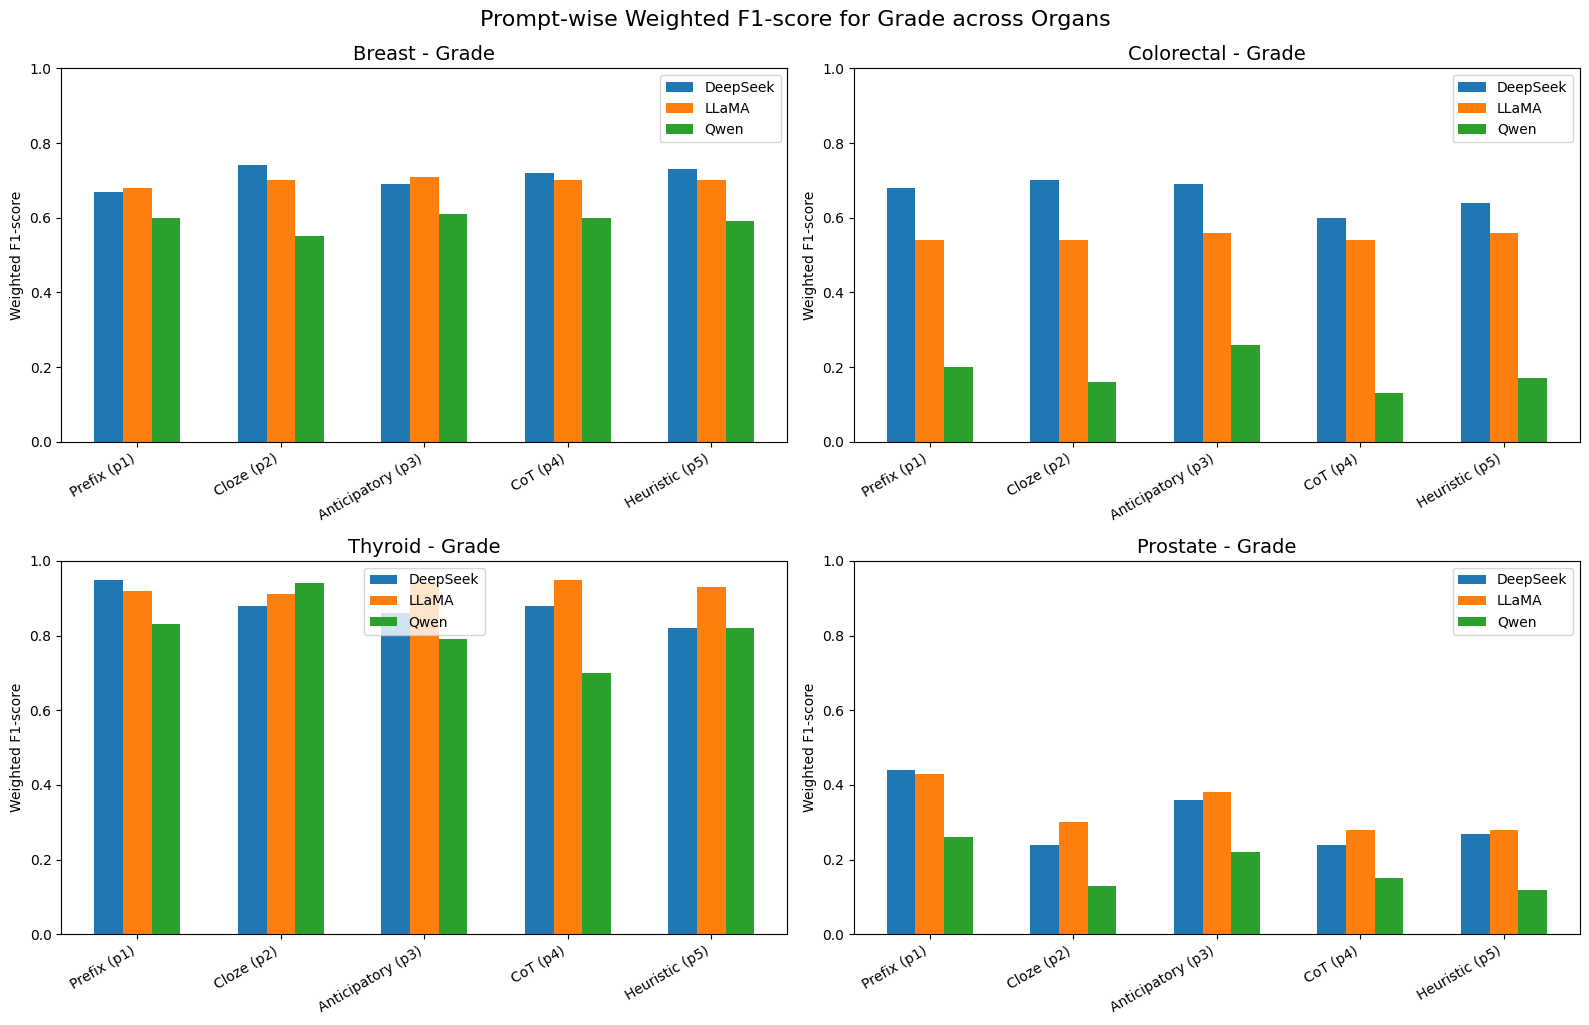

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models, Prompts, Organs
models = ['DeepSeek', 'LLaMA', 'Qwen']
prompts = ['Prefix (p1)', 'Cloze (p2)', 'Anticipatory (p3)', 'CoT (p4)', 'Heuristic (p5)']
organs = ['Breast', 'Colorectal', 'Thyroid', 'Prostate']

# Weighted F1-scores for each model × prompt × organ
scores = {
    'Breast': {
        'DeepSeek': [0.67, 0.74, 0.69, 0.72, 0.73],
        'LLaMA':    [0.68, 0.70, 0.71, 0.70, 0.70],
        'Qwen':     [0.60, 0.55, 0.61, 0.60, 0.59]
    },
    'Colorectal': {
        'DeepSeek': [0.68, 0.70, 0.69, 0.60, 0.64],
        'LLaMA':    [0.54, 0.54, 0.56, 0.54, 0.56],
        'Qwen':     [0.20, 0.16, 0.26, 0.13, 0.17]
    },
    'Thyroid': {
        'DeepSeek': [0.95, 0.88, 0.86, 0.88, 0.82],
        'LLaMA':    [0.92, 0.91, 0.94, 0.95, 0.93],
        'Qwen':     [0.83, 0.94, 0.79, 0.70, 0.82]
    },
    'Prostate': {
        'DeepSeek': [0.44, 0.24, 0.36, 0.24, 0.27],
        'LLaMA':    [0.43, 0.30, 0.38, 0.28, 0.28],
        'Qwen':     [0.26, 0.13, 0.22, 0.15, 0.12]
    }
}

# Plotting setup
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

bar_width = 0.2
x = np.arange(len(prompts))

for i, organ in enumerate(organs):
    ax = axes[i]

    for j, model in enumerate(models):
        offset = (j - 1) * bar_width  # center-align
        y = scores[organ][model]
        ax.bar(x + offset, y, width=bar_width, label=model)

    ax.set_title(f'{organ} - Grade', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(prompts, rotation=30, ha='right')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Weighted F1-score')
    ax.legend()

plt.tight_layout()
plt.suptitle('Prompt-wise Weighted F1-score for Grade across Organs', fontsize=16, y=1.02)
plt.show()


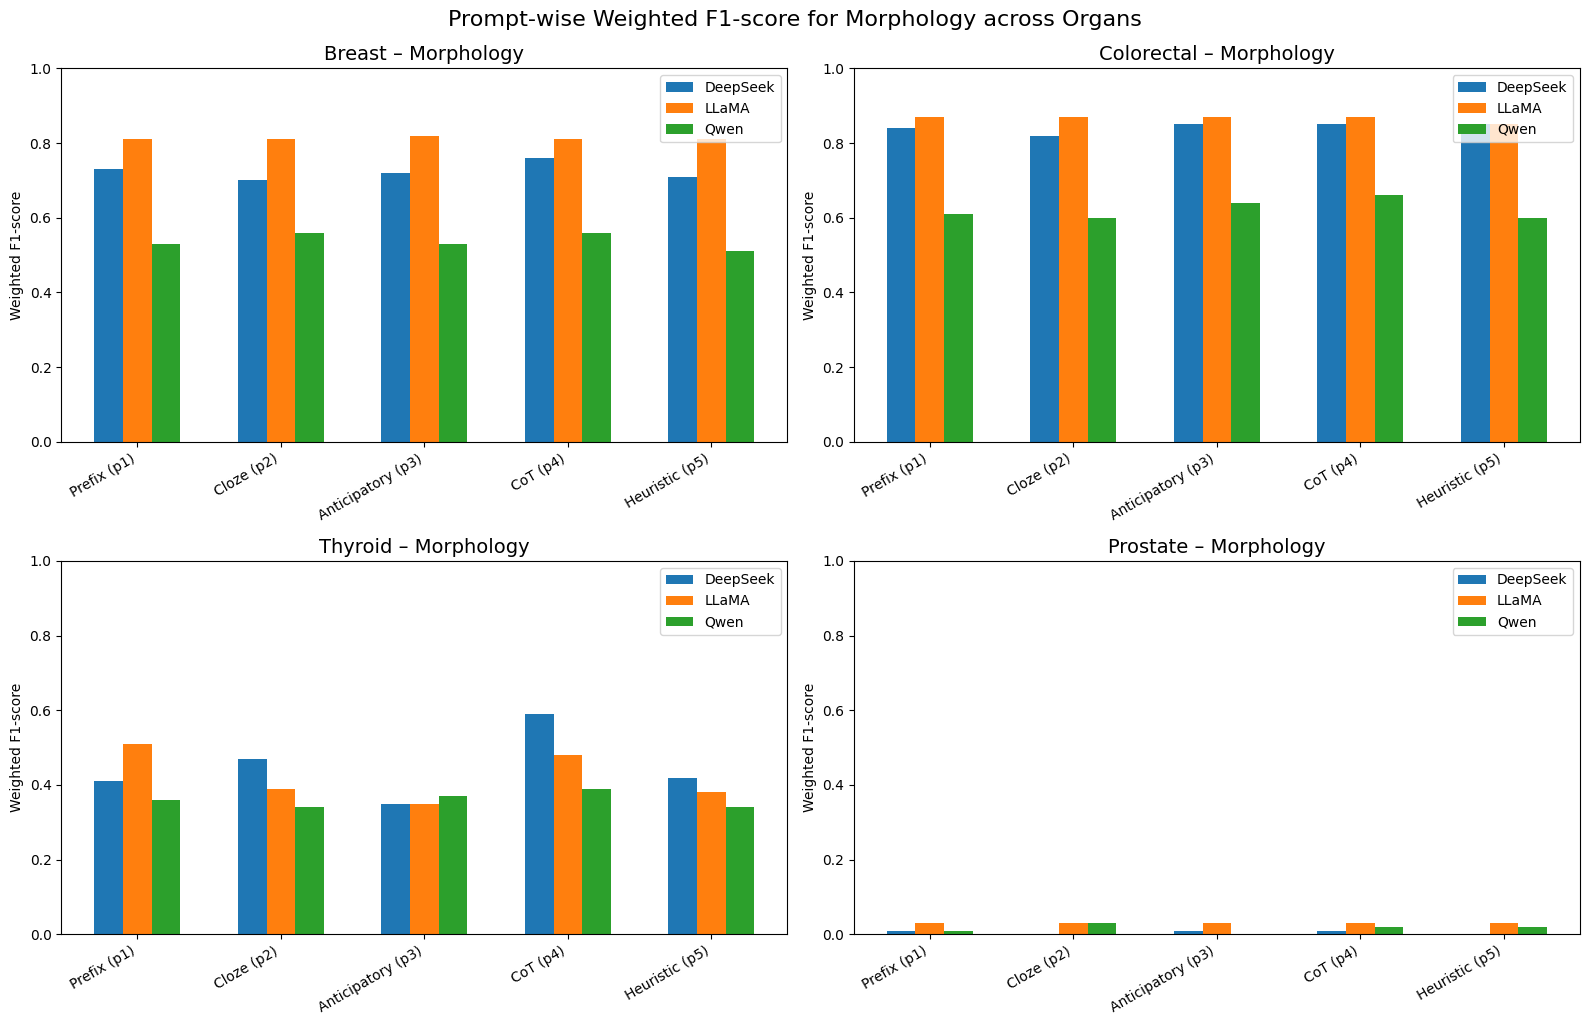

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models, Prompts, Organs (Sites)
models = ['DeepSeek', 'LLaMA', 'Qwen']
prompts = ['Prefix (p1)', 'Cloze (p2)', 'Anticipatory (p3)', 'CoT (p4)', 'Heuristic (p5)']
organs = ['Breast', 'Colorectal', 'Thyroid', 'Prostate']

# Morphology F1 scores for each model × prompt × organ (exact values from image)
scores = {
    'Breast': {
        'DeepSeek': [0.73, 0.70, 0.72, 0.76, 0.71],
        'LLaMA':    [0.81, 0.81, 0.82, 0.81, 0.81],
        'Qwen':     [0.53, 0.56, 0.53, 0.56, 0.51]
    },
    'Colorectal': {
        'DeepSeek': [0.84, 0.82, 0.85, 0.85, 0.85],
        'LLaMA':    [0.87, 0.87, 0.87, 0.87, 0.85],
        'Qwen':     [0.61, 0.60, 0.64, 0.66, 0.60]
    },
    'Thyroid': {
        'DeepSeek': [0.41, 0.47, 0.35, 0.59, 0.42],
        'LLaMA':    [0.51, 0.39, 0.35, 0.48, 0.38],
        'Qwen':     [0.36, 0.34, 0.37, 0.39, 0.34]
    },
    'Prostate': {
        'DeepSeek': [0.01, 0.00, 0.01, 0.01, 0.00],
        'LLaMA':    [0.03, 0.03, 0.03, 0.03, 0.03],
        'Qwen':     [0.01, 0.03, 0.00, 0.02, 0.02]
    }
}

# Plotting setup
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
bar_width = 0.2
x = np.arange(len(prompts))

for i, organ in enumerate(organs):
    ax = axes[i]

    for j, model in enumerate(models):
        offset = (j - 1) * bar_width  # center-align
        y = scores[organ][model]
        ax.bar(x + offset, y, width=bar_width, label=model)

    ax.set_title(f'{organ} – Morphology', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(prompts, rotation=30, ha='right')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Weighted F1-score')
    ax.legend()

plt.tight_layout()
plt.suptitle('Prompt-wise Weighted F1-score for Morphology across Organs', fontsize=16, y=1.02)
plt.show()


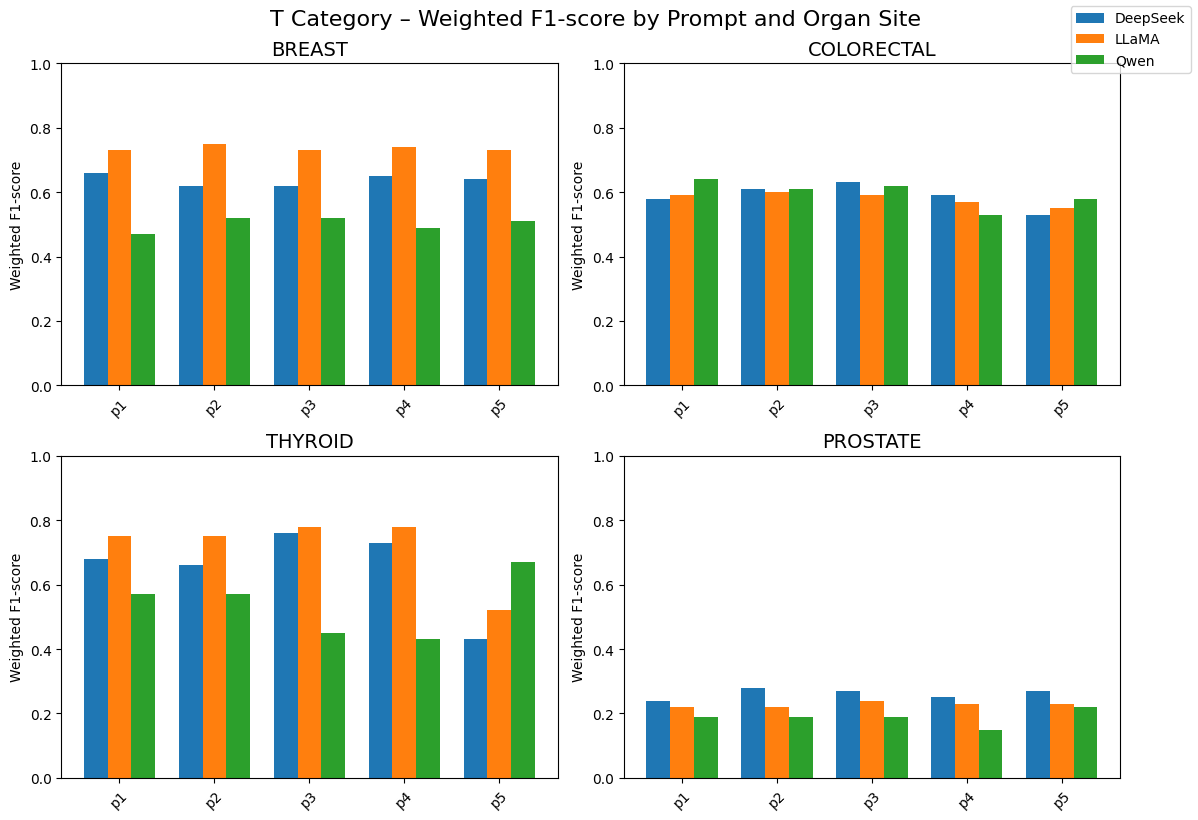

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define prompts and organ sites
prompts = ['p1', 'p2', 'p3', 'p4', 'p5']
sites = ['BREAST', 'COLORECTAL', 'THYROID', 'PROSTATE']

# Data from T category (Weighted F1-score)
deepseek_t = [0.66, 0.62, 0.62, 0.65, 0.64]
lama_t = [0.73, 0.75, 0.73, 0.74, 0.73]
qwen_t = [0.47, 0.52, 0.52, 0.49, 0.51]

deepseek_c = [0.58, 0.61, 0.63, 0.59, 0.53]
lama_c = [0.59, 0.60, 0.59, 0.57, 0.55]
qwen_c = [0.64, 0.61, 0.62, 0.53, 0.58]

deepseek_y = [0.68, 0.66, 0.76, 0.73, 0.43]
lama_y = [0.75, 0.75, 0.78, 0.78, 0.52]
qwen_y = [0.57, 0.57, 0.45, 0.43, 0.67]

deepseek_p = [0.24, 0.28, 0.27, 0.25, 0.27]
lama_p = [0.22, 0.22, 0.24, 0.23, 0.23]
qwen_p = [0.19, 0.19, 0.19, 0.15, 0.22]

# Organizing data for loop
data = {
    'BREAST': [deepseek_t, lama_t, qwen_t],
    'COLORECTAL': [deepseek_c, lama_c, qwen_c],
    'THYROID': [deepseek_y, lama_y, qwen_y],
    'PROSTATE': [deepseek_p, lama_p, qwen_p]
}

# Colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
models = ['DeepSeek', 'LLaMA', 'Qwen']

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, site in enumerate(sites):
    ax = axs[i]
    values = data[site]
    x = np.arange(len(prompts))
    width = 0.25

    for j in range(3):
        ax.bar(x + width * j, values[j], width=width, color=colors[j], label=models[j] if i == 0 else "")

    ax.set_title(site, fontsize=14)
    ax.set_xticks(x + width)
    ax.set_xticklabels(prompts, rotation=45, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Weighted F1-score', fontsize=10)

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=10)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.suptitle('T Category – Weighted F1-score by Prompt and Organ Site', fontsize=16, y=1.02)
plt.show()


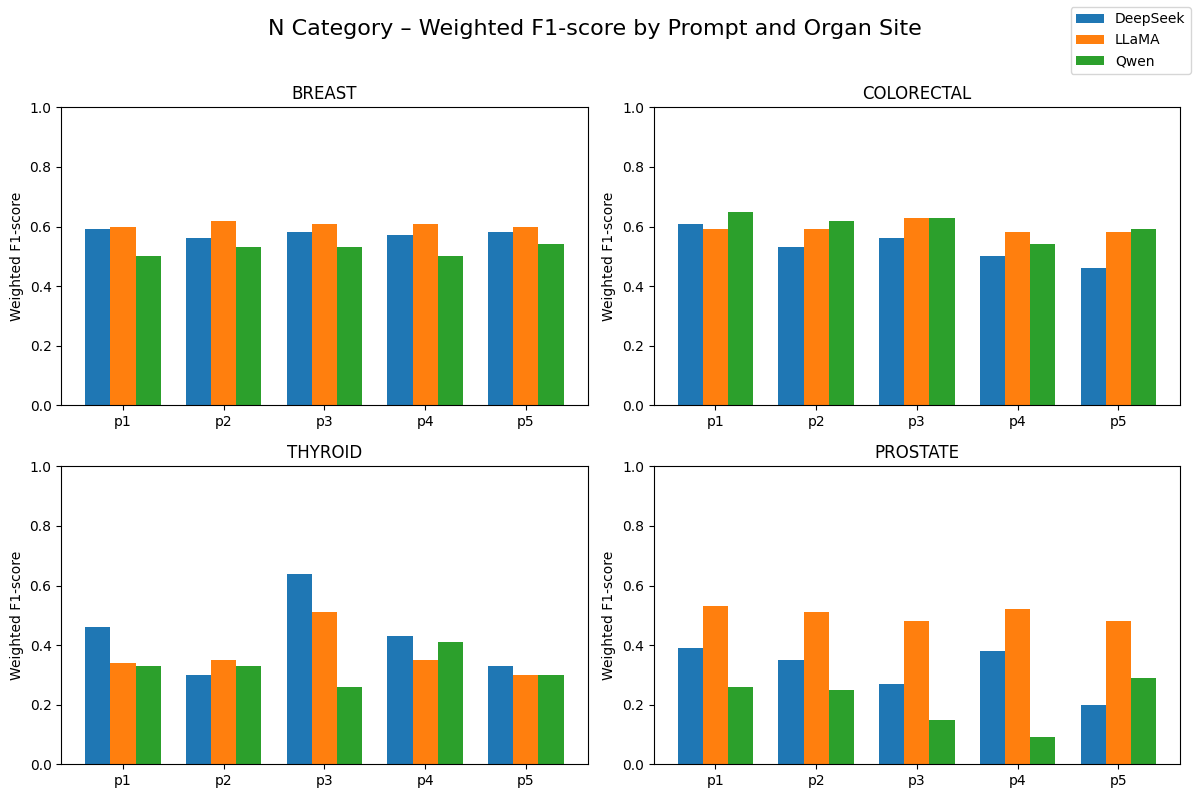

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prompt labels
prompts = ['p1', 'p2', 'p3', 'p4', 'p5']

# Model scores per organ site
deepseek = {
    'BREAST': [0.59, 0.56, 0.58, 0.57, 0.58],
    'COLORECTAL': [0.61, 0.53, 0.56, 0.50, 0.46],
    'THYROID': [0.46, 0.30, 0.64, 0.43, 0.33],
    'PROSTATE': [0.39, 0.35, 0.27, 0.38, 0.20]
}
llama = {
    'BREAST': [0.60, 0.62, 0.61, 0.61, 0.60],
    'COLORECTAL': [0.59, 0.59, 0.63, 0.58, 0.58],
    'THYROID': [0.34, 0.35, 0.51, 0.35, 0.30],
    'PROSTATE': [0.53, 0.51, 0.48, 0.52, 0.48]
}
qwen = {
    'BREAST': [0.50, 0.53, 0.53, 0.50, 0.54],
    'COLORECTAL': [0.65, 0.62, 0.63, 0.54, 0.59],
    'THYROID': [0.33, 0.33, 0.26, 0.41, 0.30],
    'PROSTATE': [0.26, 0.25, 0.15, 0.09, 0.29]
}

colors = {
    'DeepSeek': '#1f77b4',  # Blue
    'LLaMA': '#ff7f0e',     # Orange
    'Qwen': '#2ca02c'       # Green
}

# Plot configuration
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('N Category – Weighted F1-score by Prompt and Organ Site', fontsize=16)

organ_sites = ['BREAST', 'COLORECTAL', 'THYROID', 'PROSTATE']
models = ['DeepSeek', 'LLaMA', 'Qwen']

# Plotting
for ax, organ in zip(axs.flat, organ_sites):
    x = np.arange(len(prompts))
    width = 0.25
    ax.bar(x - width, deepseek[organ], width, label='DeepSeek', color=colors['DeepSeek'])
    ax.bar(x, llama[organ], width, label='LLaMA', color=colors['LLaMA'])
    ax.bar(x + width, qwen[organ], width, label='Qwen', color=colors['Qwen'])

    ax.set_title(organ)
    ax.set_xticks(x)
    ax.set_xticklabels(prompts)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Weighted F1-score')

# Legend only once
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


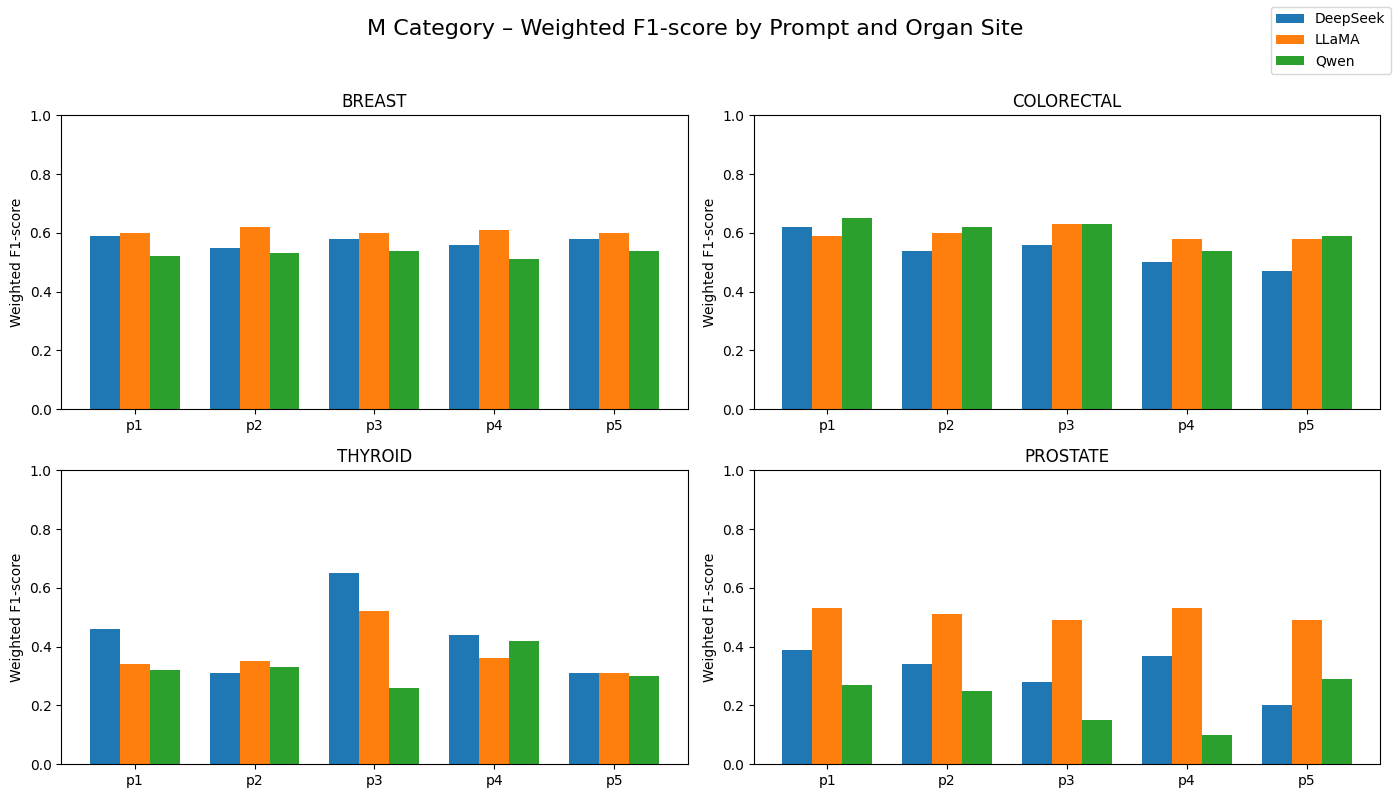

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for each site and prompt
data = {
    "BREAST": {
        "DeepSeek": [0.59, 0.55, 0.58, 0.56, 0.58],
        "LLaMA": [0.6, 0.62, 0.6, 0.61, 0.6],
        "Qwen": [0.52, 0.53, 0.54, 0.51, 0.54]
    },
    "COLORECTAL": {
        "DeepSeek": [0.62, 0.54, 0.56, 0.5, 0.47],
        "LLaMA": [0.59, 0.6, 0.63, 0.58, 0.58],
        "Qwen": [0.65, 0.62, 0.63, 0.54, 0.59]
    },
    "THYROID": {
        "DeepSeek": [0.46, 0.31, 0.65, 0.44, 0.31],
        "LLaMA": [0.34, 0.35, 0.52, 0.36, 0.31],
        "Qwen": [0.32, 0.33, 0.26, 0.42, 0.3]
    },
    "PROSTATE": {
        "DeepSeek": [0.39, 0.34, 0.28, 0.37, 0.2],
        "LLaMA": [0.53, 0.51, 0.49, 0.53, 0.49],
        "Qwen": [0.27, 0.25, 0.15, 0.1, 0.29]
    }
}

# Plotting
prompts = ['p1', 'p2', 'p3', 'p4', 'p5']
models = ['DeepSeek', 'LLaMA', 'Qwen']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("M Category – Weighted F1-score by Prompt and Organ Site", fontsize=16)

for ax, (site, scores) in zip(axs.flatten(), data.items()):
    x = np.arange(len(prompts))
    width = 0.25

    for i, (model, color) in enumerate(zip(models, colors)):
        ax.bar(x + i * width, scores[model], width, label=model if site == 'BREAST' else "", color=color)

    ax.set_title(site)
    ax.set_xticks(x + width)
    ax.set_xticklabels(prompts)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Weighted F1-score')

# Only one legend for all
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


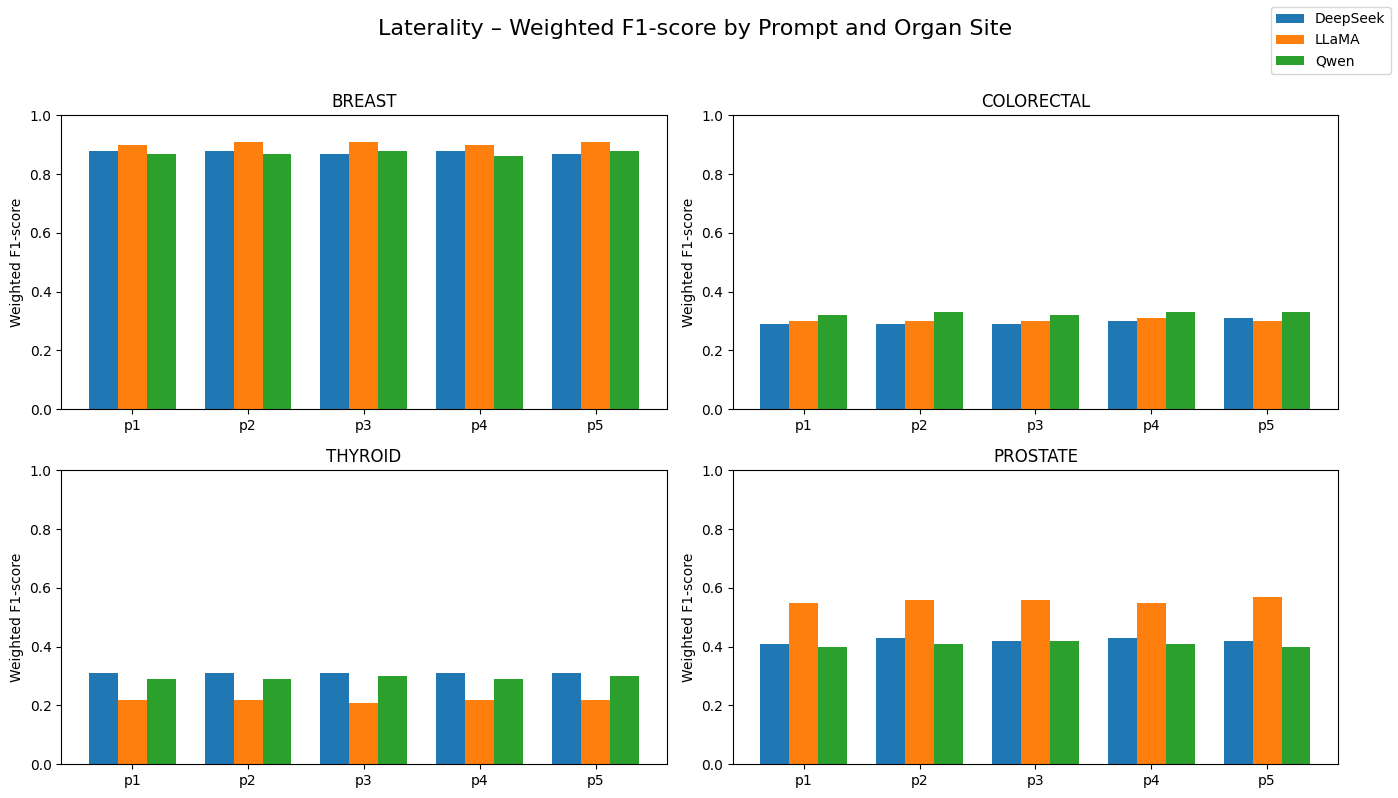

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prompt labels
prompts = ['p1', 'p2', 'p3', 'p4', 'p5']
x = np.arange(len(prompts))
width = 0.25

# Weighted F1-score data for Laterality — Replace with real values if needed
deepseek_scores = {
    'BREAST':     [0.88, 0.88, 0.87, 0.88, 0.87],
    'COLORECTAL': [0.29, 0.29, 0.29, 0.30, 0.31],
    'THYROID':    [0.31, 0.31, 0.31, 0.31, 0.31],
    'PROSTATE':   [0.41, 0.43, 0.42, 0.43, 0.42],
}

llama_scores = {
    'BREAST':     [0.90, 0.91, 0.91, 0.90, 0.91],
    'COLORECTAL': [0.30, 0.30, 0.30, 0.31, 0.30],
    'THYROID':    [0.22, 0.22, 0.21, 0.22, 0.22],
    'PROSTATE':   [0.55, 0.56, 0.56, 0.55, 0.57],
}

qwen_scores = {
    'BREAST':     [0.87, 0.87, 0.88, 0.86, 0.88],
    'COLORECTAL': [0.32, 0.33, 0.32, 0.33, 0.33],
    'THYROID':    [0.29, 0.29, 0.30, 0.29, 0.30],
    'PROSTATE':   [0.40, 0.41, 0.42, 0.41, 0.40],
}

# Organ sites
organ_sites = ['BREAST', 'COLORECTAL', 'THYROID', 'PROSTATE']

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Laterality – Weighted F1-score by Prompt and Organ Site', fontsize=16)

for idx, organ in enumerate(organ_sites):
    row, col = divmod(idx, 2)
    ax = axs[row, col]

    ax.bar(x - width, deepseek_scores[organ], width, label='DeepSeek')
    ax.bar(x, llama_scores[organ], width, label='LLaMA')
    ax.bar(x + width, qwen_scores[organ], width, label='Qwen')

    ax.set_title(organ)
    ax.set_xticks(x)
    ax.set_xticklabels(prompts)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Weighted F1-score')

# Add legend only once
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout(rect=[0, 0, 0.97, 0.95])
plt.show()


#Regex

In [3]:
import pandas as pd

# Load file
df = pd.read_csv("/content/combined_dataframe_regex.csv")

# Filter TOPO cases (change "BREAST" to any site)
topo_filter = "COLORECTAL"
subset = df[df["TOPO"].str.contains(topo_filter, case=False, na=False)]

# Display value counts for LATER (pred)
subset["MORP (pred)"].value_counts()


,count
MORP (pred),
unknown,79
mucinous adenocarcinoma,4
signet ring cell carcinoma,4
infiltrating or invasive lobular carcinoma of no special type,2
infiltrating or invasive ductal carcinoma of no special type,1
carcinoma with neuroendocrine differentiation,1


In [4]:
df = df.drop(columns=["text"])
df

,mrn,TOPO,MORP,GRADE,T,N,M,STAGE,LATER,TRE-1,site,T(pred),N(pred),M(pred),TOPO (pred),MORP (pred),GRADE (pred),STAGE (pred),TRE (pred),LATER (pred)
0,1082698,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade iii; also called poorly diffe...,t3,n0,m0,iib,left,surgery+chemotherapy+radiotherapy+hormonal,NaN,t3,n0,m0,BREAST,ductal carcinoma in situ (dcis),grade 3 or grade iii; also called poorly diffe...,unknown,"Hormonal therapy, Chemotherapy, Radiotherapy, ...",left
1,1092552,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 3 or grade iii; also called poorly diffe...,t4b,n0,m0,iiia,right,neoadjuvant chemotherapy+surgery+radiotherapy+...,NaN,unknown,n0,m0,BREAST,infiltrating or invasive ductal carcinoma of n...,grade 2 or grade ii; also called moderately d...,iia,"Hormonal therapy, Chemotherapy, Surgery, Radio...",left
2,1279594,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade ii; also called moderately d...,t3,n1,mx,iiib,"right, transverse colon",chemotherapy + surgery,NaN,t3,n1,m0,COLORECTAL,unknown,unknown,iiib,"Chemotherapy, Surgery",bilateral involvement
3,1389006,COLORECTAL,adenocarcinoma of no special type,grade 2 or grade ii; also called moderately d...,t3,n0,m0,iib,left,chemotherapy + surgery,NaN,t3,n0,m0,COLORECTAL,infiltrating or invasive lobular carcinoma of ...,grade 1 or grade i; also called well-different...,ii,"Chemotherapy, Radiotherapy, Surgery",bilateral involvement
4,1215135,BREAST,mucinous carcinoma,grade 2 or grade ii; also called moderately d...,t2,n0,m0,iia,left,surgery+chemotherapy+radiotherapy+hormonal,NaN,unknown,n0,m0,BREAST,ductal carcinoma in situ (dcis),grade 2 or grade ii; also called moderately d...,unknown,"Chemotherapy, Surgery, Radiotherapy",bilateral involvement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,1359023,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,thyroid,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,unknown
574,1365405,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,thyroid,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,left
575,1365411,THYROID,papillary carcinoma,unknown,unknown,unknown,unknown,i,unknown,total thyroidectomy,thyroid,unknown,unknown,unknown,THYROID,papillary carcinoma,unknown,unknown,NaN,unknown
576,1365420,THYROID,papillary carcinoma,unknown,unknown,n1,unknown,i,unknown,total thyroidectomy,thyroid,t4,unknown,unknown,THYROID,infiltrating or invasive ductal carcinoma of n...,unknown,unknown,Surgery,bilateral involvement


In [5]:
df["MORP"].value_counts()

,count
MORP,
infiltrating or invasive ductal carcinoma of no special type,253
acinar adenocarcinoma,101
adenocarcinoma of no special type,85
papillary carcinoma,80
infiltrating or invasive lobular carcinoma of no special type,24
mucinous adenocarcinoma,5
mucinous carcinoma,4
unknown,4
follicular carcinoma,4


In [6]:
df['T(pred)'].value_counts()

,count
T(pred),
unknown,311
t2,105
t3,83
t4,55
t1,24


##Morphology-colorectal

In [7]:
!pip install rapidfuzz

In [8]:
# ============================================
# 0. IMPORTS
# ============================================
import pandas as pd
import re
from rapidfuzz import process, fuzz

# ============================================
# 1. LOAD DATA
# ============================================
df = pd.read_csv("/content/combined_dataframe_regex.csv")

# ============================================
# 2. NORMALIZATION FUNCTION
# ============================================
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    return re.sub(r"\s{2,}", " ", str(label).strip().lower())

df["MORP_GT_NORM"] = df["MORP"].apply(normalize_label)
df["MORP_PRED_NORM"] = df["MORP (pred)"].apply(normalize_label)

# ============================================
# 3. FULL GROUND-TRUTH MORPHOLOGY LABEL SET
# ============================================
morph_label_set = [
    "infiltrating or invasive ductal carcinoma of no special type",
    "acinar adenocarcinoma",
    "adenocarcinoma of no special type",
    "papillary carcinoma",
    "infiltrating or invasive lobular carcinoma of no special type",
    "mucinous adenocarcinoma",
    "mucinous carcinoma",
    "unknown",
    "follicular carcinoma",
    "invasive breast carcinoma of no special type",
    "medullary carcinoma",
    "ductal carcinoma in situ (dcis)",
    "carcinoma with apocrine differentiation",
    "metaplastic carcinoma",
    "phyllodes tumor, malignant",
    "carcinoma of no special type",
    "carcinoma, anaplastic, nos",
    "invasive ductal carcinoma with neuroendocrine differentiation",
    "micropapillary carcinoma",
    "signet ring cell carcinoma"
]

# ============================================
# 4. RULE + FUZZY MAPPING FUNCTION
# ============================================
def map_morphology_to_gt(text):
    if pd.isnull(text) or text == "" or text == "unknown":
        return "unknown", 0

    t = normalize_label(text)

    # --------------------------------------------
    # STRONG RULE-BASED MATCHING
    # --------------------------------------------
    if "invasive duct" in t or "ductal carcinoma" in t:
        return "infiltrating or invasive ductal carcinoma of no special type", 100

    if "lobular" in t:
        return "infiltrating or invasive lobular carcinoma of no special type", 100

    if "acinar" in t:
        return "acinar adenocarcinoma", 100

    if "mucinous" in t:
        if "adeno" in t:
            return "mucinous adenocarcinoma", 100
        else:
            return "mucinous carcinoma", 100

    if "papillary" in t:
        return "papillary carcinoma", 100

    if "adenocarcinoma" in t:
        return "adenocarcinoma of no special type", 100

    if "follicular" in t:
        return "follicular carcinoma", 100

    if "medullary" in t:
        return "medullary carcinoma", 100

    if "apocrine" in t:
        return "carcinoma with apocrine differentiation", 100

    if "metaplastic" in t:
        return "metaplastic carcinoma", 100

    if "phyllodes" in t:
        return "phyllodes tumor, malignant", 100

    if "signet ring" in t:
        return "signet ring cell carcinoma", 100

    if "micropapillary" in t:
        return "micropapillary carcinoma", 100

    if "dcis" in t:
        return "ductal carcinoma in situ (dcis)", 100

    if "anaplastic" in t:
        return "carcinoma, anaplastic, nos", 100

    # --------------------------------------------
    # FUZZY MATCHING
    # --------------------------------------------
    result = process.extractOne(t, morph_label_set, scorer=fuzz.WRatio)

    if result:
        match, score = result[0], result[1]
        if score >= 70:   # fuzzy threshold
            return match, score

    return "unknown", 0

# ============================================
# 5. APPLY MAPPING
# ============================================
df["MORP_MATCH_RESULT"] = df["MORP_PRED_NORM"].apply(map_morphology_to_gt)
df["MORP_PRED_MAPPED"] = df["MORP_MATCH_RESULT"].apply(lambda x: x[0])
df["MORP_MATCH_SCORE"] = df["MORP_MATCH_RESULT"].apply(lambda x: x[1])

# ============================================
# 6. BUILD FINAL REVIEW TABLE
# ============================================
morph_review = df[[
    "mrn",
    "TOPO",
    "MORP",
    "MORP_GT_NORM",
    "MORP (pred)",
    "MORP_PRED_NORM",
    "MORP_PRED_MAPPED",
    "MORP_MATCH_SCORE"
]]
# Filter colorectal cases from morph_review
colorectal_morph = morph_review[
    morph_review["TOPO"].str.contains("colorectal", case=False, na=False)
]

# Save to CSV
colorectal_morph.to_csv("/content/regex_morph_review_colorectal.csv", index=False)
pd.set_option('display.max_rows', None)
colorectal_morph



,mrn,TOPO,MORP,MORP_GT_NORM,MORP (pred),MORP_PRED_NORM,MORP_PRED_MAPPED,MORP_MATCH_SCORE
2,1279594,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,unknown,unknown,unknown,0.0
3,1389006,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,infiltrating or invasive lobular carcinoma of ...,infiltrating or invasive lobular carcinoma of ...,infiltrating or invasive lobular carcinoma of ...,100.0
10,1363852,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,unknown,unknown,unknown,0.0
16,1223997,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,infiltrating or invasive ductal carcinoma of n...,infiltrating or invasive ductal carcinoma of n...,infiltrating or invasive ductal carcinoma of n...,100.0
17,183374,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,unknown,unknown,unknown,0.0
24,1234081,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,unknown,unknown,unknown,0.0
30,1296072,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,mucinous adenocarcinoma,mucinous adenocarcinoma,mucinous adenocarcinoma,100.0
34,1376822,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,unknown,unknown,unknown,0.0
37,1285928,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,unknown,unknown,unknown,0.0
38,1362399,COLORECTAL,adenocarcinoma of no special type,adenocarcinoma of no special type,unknown,unknown,unknown,0.0


In [9]:
df=pd.read_csv("/content/regex_morph_review_colorectal.csv")
df.columns

Index(['mrn', 'TOPO', 'MORP', 'MORP_GT_NORM', 'MORP (pred)', 'MORP_PRED_NORM',
       'MORP_PRED_MAPPED', 'MORP_MATCH_SCORE'],
      dtype='object')

In [10]:
import numpy as np
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from IPython.display import display
# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": df["MORP_GT_NORM"],
    "pred": df["MORP_PRED_MAPPED"].apply(normalize_label)
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# Error Profile
unknowns = (y_pred == "unknown").sum()
misclassified = (y_pred != y_true).sum() - unknowns
overpredicted = (
    ~y_pred.isin(y_true.unique()) & (y_pred != "unknown")
).sum()
total = len(combined_df)
error_profile = {
    "Overprediction %": round((overpredicted / total) * 100, 2),
    "Misclassification %": round((misclassified / total) * 100, 2),
    "Unknown %": round((unknowns / total) * 100, 2),
}

# Bootstrapped Metrics
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (colorectal RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)



📊 EVALUATION SUMMARY (colorectal RECORDS ONLY)
weighted Precision:  0.0503
weighted Recall:     0.0420
Macro F1:         0.1503  (95% CI: 0.0000, 0.3015)
Weighted F1:      0.0426  (95% CI: 0.0000, 0.1044)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(4.4), 'Misclassification %': np.float64(8.79), 'Unknown %': np.float64(86.81)}


##Grade-thyroid

In [11]:
# ============================================
# 0. IMPORTS
# ============================================
import pandas as pd
import re
from rapidfuzz import process, fuzz


# ============================================
# 1. LOAD DATA
# ============================================
df = pd.read_csv("/content/combined_dataframe_regex.csv")


# ============================================
# 2. NORMALIZATION FUNCTION
# ============================================
def normalize_label(label):
    if pd.isnull(label):
        return "unknown"
    return re.sub(r"\s+", " ", str(label).strip().lower())


# ============================================
# 3. MANUAL GRADE MAP
# ============================================
manual_grade_map = {
    "i": "grade 1 or grade i; also called well-differentiated",
    "1": "grade 1 or grade i; also called well-differentiated",
    "ii": "grade 2 or grade ii; also called moderately differentiated",
    "2": "grade 2 or grade ii; also called moderately differentiated",
    "iii": "grade 3 or grade iii; also called poorly differentiated",
    "3": "grade 3 or grade iii; also called poorly differentiated",

    "grade1": "grade 1 or grade i; also called well-differentiated",
    "grade2": "grade 2 or grade ii; also called moderately differentiated",
    "grade3": "grade 3 or grade iii; also called poorly differentiated",

    "g1": "grade 1 or grade i; also called well-differentiated",
    "g2": "grade 2 or grade ii; also called moderately differentiated",
    "g3": "grade 3 or grade iii; also called poorly differentiated",

    # Gleason scores (ignored for thyroid)
    "gleasonscore3+3=6": "group 1 (gleason score 3 + 3 = 6)",
    "gleasonscore3+4=7": "group 2 (gleason score 3 + 4 = 7)",
    "gleasonscore4+4=8": "group 4 (gleason score 4 + 4 = 8)",
    "gleasonscore5+4=9": "group 5 (gleason score 5 + 4 = 9)",
    "6": "group 1 (gleason score 3 + 3 = 6)",
    "7": "group 2 (gleason score 3 + 4 = 7)",
    "8": "group 4 (gleason score 4 + 4 = 8)",
    "9": "group 5 (gleason score 5 + 4 = 9)"
}


# ============================================
# 4. THYROID ALLOWED GRADE LABELS
# ============================================
site_labels = {
    "THYROID": [
        "grade 1 or grade i; also called well-differentiated",
        "grade 2 or grade ii; also called moderately differentiated",
        "grade 3 or grade iii; also called poorly differentiated",
        "unknown"
    ]
}


# ============================================
# 5. MAPPING FUNCTION (Manual + Fuzzy)
# ============================================
def match_grade_with_manual_and_fuzzy(text, topo, threshold=70):

    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    topo = str(topo).upper()

    if topo not in site_labels:
        return "unknown", 0

    cleaned = normalize_label(text).replace(" ", "")

    # ---- Manual mapping ----
    if cleaned in manual_grade_map:
        mapped = manual_grade_map[cleaned]
        if mapped in site_labels[topo]:
            return mapped, 100

    # ---- Fuzzy fallback ----
    result = process.extractOne(
        normalize_label(text),
        site_labels[topo],
        scorer=fuzz.WRatio
    )

    if result:
        match, score = result[0], result[1]
        if score >= threshold:
            return match, score

    return "unknown", 0


# ============================================
# 6. FILTER ONLY THYROID CASES
# ============================================
thyroid_df = df[df["TOPO"].str.contains("thyroid", case=False, na=False)].copy()


# ============================================
# 7. MAP BOTH GT GRADE AND PRED GRADE
# ============================================
thyroid_df["GRADE_GT_RESULT"] = thyroid_df.apply(
    lambda row: match_grade_with_manual_and_fuzzy(row["GRADE"], row["TOPO"]),
    axis=1
)
thyroid_df["GRADE_GT_MAPPED"] = thyroid_df["GRADE_GT_RESULT"].apply(lambda x: x[0])

thyroid_df["GRADE_PRED_RESULT"] = thyroid_df.apply(
    lambda row: match_grade_with_manual_and_fuzzy(row["GRADE (pred)"], row["TOPO"]),
    axis=1
)
thyroid_df["GRADE_PRED_MAPPED"] = thyroid_df["GRADE_PRED_RESULT"].apply(lambda x: x[0])
thyroid_df["GRADE_MATCH_SCORE"] = thyroid_df["GRADE_PRED_RESULT"].apply(lambda x: x[1])


# ============================================
# 8. BUILD FINAL REVIEW TABLE
# ============================================
thyroid_grade_review = thyroid_df[[
    "mrn",
    "TOPO",
    "GRADE",
    "GRADE_GT_MAPPED",
    "GRADE (pred)",
    "GRADE_PRED_MAPPED",
    "GRADE_MATCH_SCORE"
]]

# Show ALL rows
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
# Save thyroid grade review to CSV
thyroid_grade_review.to_csv("/content/regex_grade_review_thyroid.csv", index=False)

print("Saved to /content/regex_grade_review_thyroid.csv")


thyroid_grade_review


Saved to /content/regex_grade_review_thyroid.csv


,mrn,TOPO,GRADE,GRADE_GT_MAPPED,GRADE (pred),GRADE_PRED_MAPPED,GRADE_MATCH_SCORE
11,1266302,THYROID,unknown,unknown,grade 1 or grade i; also called well-differentiated,grade 1 or grade i; also called well-differentiated,100.0
123,1270724,THYROID,unknown,unknown,unknown,unknown,100.0
199,1237716,THYROID,unknown,unknown,unknown,unknown,100.0
279,1080335,THYROID,unknown,unknown,grade 1 or grade i; also called well-differentiated,grade 1 or grade i; also called well-differentiated,100.0
376,1336552,THYROID,not applicable,unknown,unknown,unknown,100.0
497,5177,THYROID,unknown,unknown,unknown,unknown,100.0
498,37439,THYROID,unknown,unknown,unknown,unknown,100.0
499,45652,THYROID,unknown,unknown,unknown,unknown,100.0
500,46519,THYROID,unknown,unknown,unknown,unknown,100.0
501,83393,THYROID,unknown,unknown,grade 1 or grade i; also called well-differentiated,grade 1 or grade i; also called well-differentiated,100.0


In [12]:
import pandas as pd
df=pd.read_csv("/content/regex_grade_review_thyroid.csv")
df.columns

Index(['mrn', 'TOPO', 'GRADE', 'GRADE_GT_MAPPED', 'GRADE (pred)',
       'GRADE_PRED_MAPPED', 'GRADE_MATCH_SCORE'],
      dtype='object')

In [13]:
import numpy as np
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from IPython.display import display
# -------------------------------------------------------
# FIXED EVALUATION LOGIC (NO NEGATIVE VALUES)
# -------------------------------------------------------

combined_df = pd.DataFrame({
    "true": df["GRADE_GT_MAPPED"],
    "pred": df["GRADE_PRED_MAPPED"]
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# ------------- Error Categories -----------------

# Unknown predictions
unknown_mask = (y_pred == "unknown")

# Overprediction: GT unknown, pred is a real grade
over_mask = (y_true == "unknown") & (y_pred != "unknown")

# Misclassification: both real labels but mismatched
mis_mask = (y_true != "unknown") & (y_pred != "unknown") & (y_true != y_pred)

# Counts
unknowns = unknown_mask.sum()
overpredicted = over_mask.sum()
misclassified = mis_mask.sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2)
}

# Bootstrapped Metrics
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (thyroid RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)



📊 EVALUATION SUMMARY (thyroid RECORDS ONLY)
weighted Precision:  1.0000
weighted Recall:     0.8693
Macro F1:         0.2865  (95% CI: 0.2196, 0.4806)
Weighted F1:      0.9295  (95% CI: 0.8673, 0.9655)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(12.79), 'Misclassification %': np.float64(0.0), 'Unknown %': np.float64(87.21)}


##T-thyroid

In [14]:
# ============================================
# 0. IMPORTS
# ============================================
import pandas as pd
import re
from rapidfuzz import process, fuzz


# ============================================
# 1. LOAD DATA
# ============================================
df = pd.read_csv("/content/combined_dataframe_regex.csv")


# ============================================
# 2. ALLOWED T-LABELS FOR THYROID
# ============================================
t_labels = ["t1", "t2", "t3", "t4", "tis", "unknown"]


# ============================================
# 3. NORMALIZATION + MAPPING FUNCTION FOR T
# ============================================
from rapidfuzz import process, fuzz
import re

# -----------------------------------------
# Final Ground-Truth T Labels
# -----------------------------------------
t_label_set = ["t1", "t2", "t3", "t4", "unknown"]

# -----------------------------------------
# Normalization Function
# -----------------------------------------
def normalize_t_value(text):
    if not isinstance(text, str):
        return "unknown"

    t = text.lower().strip()

    # remove all non-alphanumeric
    t = re.sub(r"[^a-z0-9]", "", t)

    # allow removing leading p/pt/yp/rp etc.
    t = re.sub(r"^(pt|p|yp|rp)", "", t)

    # -------------------------------
    # Strong rule mappings
    # -------------------------------
    if t in ["t1", "t1a", "t1b", "t1c"]:
        return "t1"

    if t == "t2":
        return "t2"

    if t in ["t3", "t3a", "t3b"]:
        return "t3"

    if t in ["t4", "t4a", "t4b", "t4c", "t4d"]:
        return "t4"

    if t in ["tis", "ptis"]:
        return "t1"   # *** or "unknown" depending on your rules
                      # but usually Tis is grouped under very early T

    if t == "" or t == "unknown":
        return "unknown"

    # -------------------------------
    # Fuzzy fallback
    # -------------------------------
    result = process.extractOne(t, t_label_set, scorer=fuzz.WRatio)

    if result:
        match, score = result[0], result[1]
        if score >= 80:
            return match

    return "unknown"


# ============================================
# 4. FILTER THYROID CASES
# ============================================
thyroid_df = df[df["TOPO"].str.contains("thyroid", case=False, na=False)].copy()


# ============================================
# 5. APPLY MAPPING TO GROUND TRUTH & PREDICTED T
# ============================================
thyroid_df["T_GT_MAPPED"] = thyroid_df["T"].apply(normalize_t_value)
thyroid_df["T_PRED_MAPPED"] = thyroid_df["T(pred)"].apply(normalize_t_value)


# ============================================
# 6. BUILD T-STAGE REVIEW TABLE
# ============================================
thyroid_t_review = thyroid_df[[
    "mrn",
    "TOPO",
    "T",
    "T_GT_MAPPED",
    "T(pred)",
    "T_PRED_MAPPED"
]]


# ============================================
# 7. DISPLAY ALL ROWS
# ============================================
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

thyroid_t_review


# ============================================
# 8. SAVE TO CSV
# ============================================
thyroid_t_review.to_csv("/content/regex_T_review_thyroid.csv", index=False)

print("Saved: /content/regex_T_review_thyroid.csv")
thyroid_t_review

Saved: /content/regex_T_review_thyroid.csv


,mrn,TOPO,T,T_GT_MAPPED,T(pred),T_PRED_MAPPED
11,1266302,THYROID,unknown,unknown,t4,t4
123,1270724,THYROID,t3,t3,unknown,unknown
199,1237716,THYROID,unknown,unknown,unknown,unknown
279,1080335,THYROID,unknown,unknown,unknown,unknown
376,1336552,THYROID,unknown,unknown,unknown,unknown
497,5177,THYROID,t3,t3,t3,t3
498,37439,THYROID,t2,t2,unknown,unknown
499,45652,THYROID,unknown,unknown,unknown,unknown
500,46519,THYROID,t4,t4,t4,t4
501,83393,THYROID,unknown,unknown,unknown,unknown


In [15]:
df=pd.read_csv("/content/regex_T_review_thyroid.csv")
df.columns

Index(['mrn', 'TOPO', 'T', 'T_GT_MAPPED', 'T(pred)', 'T_PRED_MAPPED'], dtype='object')

In [16]:
import numpy as np
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from IPython.display import display# -------------------------------------------------------
# FIXED ERROR PROFILE LOGIC FOR T-STAGE
# -------------------------------------------------------

combined_df = pd.DataFrame({
    "true": df["T_GT_MAPPED"],
    "pred": df["T_PRED_MAPPED"]
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# ---------------- Unknown ----------------
unknown_mask = (y_pred == "unknown")

# ---------------- Overprediction ----------------
# GT unknown, pred is a valid T (t1/t2/t3/t4)
over_mask = (y_true == "unknown") & (y_pred != "unknown")

# ---------------- Misclassification ----------------
# GT is a real T-stage AND pred is real AND mismatch
mis_mask = (y_true != "unknown") & (y_pred != "unknown") & (y_true != y_pred)

# ---------------- Counts ----------------
unknowns = unknown_mask.sum()
overpredicted = over_mask.sum()
misclassified = mis_mask.sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2),
}

# Bootstrapped Metrics
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (thyroid RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)



📊 EVALUATION SUMMARY (thyroid RECORDS ONLY)
weighted Precision:  0.6504
weighted Recall:     0.5900
Macro F1:         0.2675  (95% CI: 0.1713, 0.3735)
Weighted F1:      0.5897  (95% CI: 0.4531, 0.7309)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(17.44), 'Misclassification %': np.float64(5.81), 'Unknown %': np.float64(70.93)}


##N-thhyroid

In [17]:
# ============================================
# 0. IMPORTS
# ============================================
import pandas as pd
import re
from rapidfuzz import process, fuzz


# ============================================
# 1. LOAD DATA
# ============================================
df = pd.read_csv("/content/combined_dataframe_regex.csv")


# ============================================
# 2. ALLOWED N LABELS
# ============================================
n_labels = ["n0", "n1", "n2", "n3", "nx", "unknown"]


# ============================================
# 3. NORMALIZATION + MAPPING FUNCTION FOR N
# ============================================
from rapidfuzz import process, fuzz
import re

# -----------------------------------------
# Final Normalized N Label Set
# -----------------------------------------
n_label_set = ["n0", "n1", "n2", "unknown"]

# -----------------------------------------
# Normalization Function
# -----------------------------------------
def normalize_n_value(text):
    if not isinstance(text, str):
        return "unknown"

    t = text.lower().strip()
    t = re.sub(r"[^a-z0-9]", "", t)   # remove punctuation/spaces

    # -------- Strong manual mappings --------
    if t in ["n0", "pn0"]:
        return "n0"

    if t in ["n1", "n1a", "n1b", "n1c", "pn1", "pn1a", "pn1b", "pn1c"]:
        return "n1"

    if t in ["n2", "n2a", "n2b", "pn2", "pn2a", "pn2b"]:
        return "n2"

    if t in ["nx", "pnx", "unknown", ""]:
        return "unknown"

    # -------- Fuzzy fallback --------
    result = process.extractOne(t, n_label_set, scorer=fuzz.WRatio)
    if result:
        match, score = result[0], result[1]
        if score >= 75:
            return match

    return "unknown"


# ============================================
# 4. FILTER THYROID CASES ONLY
# ============================================
thyroid_df = df[df["TOPO"].str.contains("thyroid", case=False, na=False)].copy()


# ============================================
# 5. APPLY NORMALIZATION TO GT AND PREDICTED N
# ============================================
thyroid_df["N_GT_MAPPED"] = thyroid_df["N"].apply(normalize_n_value)
thyroid_df["N_PRED_MAPPED"] = thyroid_df["N(pred)"].apply(normalize_n_value)


# ============================================
# 6. BUILD REVIEW TABLE
# ============================================
thyroid_n_review = thyroid_df[[
    "mrn",
    "TOPO",
    "N",
    "N_GT_MAPPED",
    "N(pred)",
    "N_PRED_MAPPED"
]]


# ============================================
# 7. DISPLAY ALL ROWS
# ============================================
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

thyroid_n_review


# ============================================
# 8. SAVE TO CSV
# ============================================
thyroid_n_review.to_csv("/content/regex_N_review_thyroid.csv", index=False)

print("Saved: /content/regex_N_review_thyroid.csv")
thyroid_n_review

Saved: /content/regex_N_review_thyroid.csv


,mrn,TOPO,N,N_GT_MAPPED,N(pred),N_PRED_MAPPED
11,1266302,THYROID,unknown,unknown,n1,n1
123,1270724,THYROID,n1a,n1,n1,n1
199,1237716,THYROID,unknown,unknown,unknown,unknown
279,1080335,THYROID,unknown,unknown,unknown,unknown
376,1336552,THYROID,unknown,unknown,unknown,unknown
497,5177,THYROID,n0,n0,n0,n0
498,37439,THYROID,nx,unknown,unknown,unknown
499,45652,THYROID,unknown,unknown,unknown,unknown
500,46519,THYROID,n1,n1,unknown,unknown
501,83393,THYROID,n1,n1,unknown,unknown


In [18]:
df=pd.read_csv("/content/regex_N_review_thyroid.csv")
df.columns

Index(['mrn', 'TOPO', 'N', 'N_GT_MAPPED', 'N(pred)', 'N_PRED_MAPPED'], dtype='object')

In [19]:
import numpy as np
import pandas as pd
import numpy as np
import ast
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from IPython.display import display
# -------------------------------------------------------
# FIXED ERROR PROFILE LOGIC FOR N-STAGE
# -------------------------------------------------------

combined_df = pd.DataFrame({
    "true": df["N_GT_MAPPED"],
    "pred": df["N_PRED_MAPPED"]
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# ---------------- UNKNOWN ----------------
unknown_mask = (y_pred == "unknown")

# ---------------- OVERPREDICTION ----------------
# GT = unknown, PRED = valid N-stage
over_mask = (y_true == "unknown") & (y_pred != "unknown")

# ---------------- MISCLASSIFICATION ----------------
mis_mask = (y_true != "unknown") & (y_pred != "unknown") & (y_true != y_pred)

unknowns = unknown_mask.sum()
overpredicted = over_mask.sum()
misclassified = mis_mask.sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2),
}

# Bootstrapped Metrics
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (thyroid RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  (95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  (95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)



📊 EVALUATION SUMMARY (thyroid RECORDS ONLY)
weighted Precision:  0.7005
weighted Recall:     0.6755
Macro F1:         0.5294  (95% CI: 0.2788, 0.7715)
Weighted F1:      0.6272  (95% CI: 0.5076, 0.7955)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(3.49), 'Misclassification %': np.float64(1.16), 'Unknown %': np.float64(83.72)}


##M-Colorectal

In [20]:
# ============================================
# 0. IMPORTS
# ============================================
import pandas as pd
import re
from rapidfuzz import process, fuzz


# ============================================
# 1. LOAD DATA
# ============================================
df = pd.read_csv("/content/combined_dataframe_regex.csv")


# ============================================
# 2. ALLOWED M LABELS
# ============================================
m_labels = ["m0", "m1", "mx", "unknown"]


# ============================================
# 3. NORMALIZATION + MAPPING FUNCTION FOR M
# ============================================
from rapidfuzz import process, fuzz
import re
import pandas as pd

# -----------------------------------------
# Final Ground Truth M Label Set
# -----------------------------------------
m_label_set = ["m0", "m1", "mx", "unknown"]

# -----------------------------------------
# Normalize Function
# -----------------------------------------
def normalize_m_value(text):
    if not isinstance(text, str):
        return "unknown"
    text = text.lower().strip()

    # remove spaces & punctuation
    text = re.sub(r"[^a-z0-9]", "", text)

    # ---- Strong Manual Mappings ----
    if text in ["m0", "pm0"]:
        return "m0"
    if text in ["m1", "pm1"]:
        return "m1"
    if text in ["mx", "pmx"]:
        return "mx"
    if text == "" or text == "unknown":
        return "unknown"

    # ---- Fuzzy Mapping ----
    result = process.extractOne(text, m_label_set, scorer=fuzz.WRatio)
    if result:
        match = result[0]
        score = result[1]
        if score >= 80:     # threshold
            return match

    return "unknown"


# ============================================
# 4. FILTER COLORECTAL CASES
# ============================================
colorectal_df = df[df["TOPO"].str.contains("colorectal", case=False, na=False)].copy()


# ============================================
# 5. APPLY NORMALIZATION TO GT AND PREDICTED M
# ============================================
colorectal_df["M_GT_MAPPED"] = colorectal_df["M"].apply(normalize_m_value)
colorectal_df["M_PRED_MAPPED"] = colorectal_df["M(pred)"].apply(normalize_m_value)


# ============================================
# 6. BUILD M-STAGE REVIEW TABLE
# ============================================
colorectal_m_review = colorectal_df[[
    "mrn",
    "TOPO",
    "M",
    "M_GT_MAPPED",
    "M(pred)",
    "M_PRED_MAPPED"
]]


# ============================================
# 7. DISPLAY ALL ROWS
# ============================================
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)



# ============================================
# 8. SAVE TO CSV
# ============================================
colorectal_m_review.to_csv("/content/regex_M_review_colorectal.csv", index=False)

print("Saved: /content/regex_M_review_colorectal.csv")
colorectal_m_review

Saved: /content/regex_M_review_colorectal.csv


,mrn,TOPO,M,M_GT_MAPPED,M(pred),M_PRED_MAPPED
2,1279594,COLORECTAL,mx,mx,m0,m0
3,1389006,COLORECTAL,m0,m0,m0,m0
10,1363852,COLORECTAL,m1,m1,unknown,unknown
16,1223997,COLORECTAL,mx,mx,unknown,unknown
17,183374,COLORECTAL,mx,mx,m0,m0
24,1234081,COLORECTAL,m1,m1,m0,m0
30,1296072,COLORECTAL,m1,m1,unknown,unknown
34,1376822,COLORECTAL,m1,m1,m1,m1
37,1285928,COLORECTAL,unknown,unknown,unknown,unknown
38,1362399,COLORECTAL,m0,m0,unknown,unknown


In [21]:
df=pd.read_csv("/content/regex_M_review_colorectal.csv")
df.columns

Index(['mrn', 'TOPO', 'M', 'M_GT_MAPPED', 'M(pred)', 'M_PRED_MAPPED'], dtype='object')

In [22]:
import numpy as np
import pandas as pd
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from IPython.display import display

# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": df["M_GT_MAPPED"],
    "pred": df["M_PRED_MAPPED"]
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# -------------------------------------------------------
# FIXED ERROR PROFILE LOGIC FOR M-STAGE
# -------------------------------------------------------

# Unknown predictions
unknown_mask = (y_pred == "unknown")

# Overprediction = GT unknown, prediction is a real M-stage (m0 or m1)
over_mask = (y_true == "unknown") & (y_pred != "unknown")

# Misclassification = both GT and pred are valid AND mismatch
mis_mask = (y_true != "unknown") & (y_pred != "unknown") & (y_true != y_pred)

unknowns = unknown_mask.sum()
overpredicted = over_mask.sum()
misclassified = mis_mask.sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2),
}

# -------------------------------------------------------
# Bootstrapped Metrics
# -------------------------------------------------------
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (colorectal RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  "
      f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, "
      f"{np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  "
      f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, "
      f"{np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)



📊 EVALUATION SUMMARY (colorectal RECORDS ONLY)
weighted Precision:  0.7574
weighted Recall:     0.5006
Macro F1:         0.4477  (95% CI: 0.3364, 0.5651)
Weighted F1:      0.5006  (95% CI: 0.3688, 0.6315)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(0.0), 'Misclassification %': np.float64(24.18), 'Unknown %': np.float64(30.77)}


##Laterality-breast

In [23]:
import pandas as pd
import re
from rapidfuzz import process, fuzz

# ============================================================
# 1. Laterality Dictionaries
# ============================================================

site_laterality_labels = {
    "BREAST": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "COLORECTAL": ["left", "right", "right, transverse colon", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "THYROID": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
    "PROSTATE": ["left", "right", "bilateral involvement", "paired, lat. unknown", "unknown"],
}

manual_laterality_map = {
    "lt": "left", "l": "left", "left": "left",
    "rt": "right", "r": "right", "right": "right",
    "bilateral": "bilateral involvement", "bilat": "bilateral involvement", "both": "bilateral involvement",
    "paired": "paired, lat. unknown",
    "unknown": "unknown"
}

def normalize_token(x):
    if pd.isnull(x):
        return "unknown"
    return re.sub(r"\s+", "", str(x).strip().lower())


def match_laterality_with_manual_and_fuzzy(text, topo, threshold=80):
    if pd.isnull(text) or str(text).strip() == "":
        return "unknown", 0

    cleaned = normalize_token(text)

    # ---------- Manual Mapping ----------
    if cleaned in manual_laterality_map:
        mapped = manual_laterality_map[cleaned]
        if mapped in site_laterality_labels[topo]:
            return mapped, 100

    # ---------- Fuzzy Matching ----------
    result = process.extractOne(cleaned, site_laterality_labels[topo], scorer=fuzz.WRatio)

    if result:
        match = result[0]   # extract label
        score = result[1]   # extract score

        if score >= threshold:
            return match, score

    return "unknown", 0


# ============================================================
# 2. Load Data + Filter BREAST
# ============================================================

df = pd.read_csv("/content/combined_dataframe_regex.csv")
df["TOPO"] = df["TOPO"].astype(str).str.upper().str.strip()

breast_df = df[df["TOPO"] == "BREAST"].copy()

# Ground truth
breast_df["LATER"] = breast_df["LATER"].astype(str).str.lower().str.strip()


# ============================================================
# 3. *** THIS IS THE FIX ***
#    Use column:  LATER (pred)
# ============================================================

breast_df["LATER_pred_raw"] = breast_df["LATER (pred)"].astype(str).str.lower().str.strip()


# ============================================================
# 4. Apply Mapping
# ============================================================

breast_df["LATER_GT_MAPPED"] = breast_df["LATER"].apply(
    lambda x: match_laterality_with_manual_and_fuzzy(x, "BREAST")[0]
)

breast_df["LATER_PRED_MAPPED"] = breast_df["LATER_pred_raw"].apply(
    lambda x: match_laterality_with_manual_and_fuzzy(x, "BREAST")[0]
)

breast_df["LATER_PRED_SCORE"] = breast_df["LATER_pred_raw"].apply(
    lambda x: match_laterality_with_manual_and_fuzzy(x, "BREAST")[1]
)


# ============================================================
# 5. Build Review Table
# ============================================================

breast_laterality_review = breast_df[[
    "mrn", "TOPO", "LATER", "LATER_GT_MAPPED",
    "LATER_pred_raw", "LATER_PRED_MAPPED", "LATER_PRED_SCORE"
]]

pd.set_option("display.max_rows", None)

output_path = "/content/regex_laterality_review_breast.csv"

breast_laterality_review.to_csv(output_path, index=False)

print(f"Saved successfully → {output_path}")
breast_laterality_review


Saved successfully → /content/regex_laterality_review_breast.csv


,mrn,TOPO,LATER,LATER_GT_MAPPED,LATER_pred_raw,LATER_PRED_MAPPED,LATER_PRED_SCORE
0,1082698,BREAST,left,left,left,left,100.000000
1,1092552,BREAST,right,right,left,left,100.000000
4,1215135,BREAST,left,left,bilateral involvement,bilateral involvement,97.560976
5,1271618,BREAST,left,left,bilateral involvement,bilateral involvement,97.560976
6,1311223,BREAST,right,right,bilateral involvement,bilateral involvement,97.560976
7,1134179,BREAST,right,right,left,left,100.000000
8,1222870,BREAST,right,right,bilateral involvement,bilateral involvement,97.560976
9,1266532,BREAST,left,left,left,left,100.000000
12,1219343,BREAST,left,left,bilateral involvement,bilateral involvement,97.560976
13,1229180,BREAST,right,right,bilateral involvement,bilateral involvement,97.560976


In [24]:
df=pd.read_csv("/content/regex_laterality_review_breast.csv")
df.columns

Index(['mrn', 'TOPO', 'LATER', 'LATER_GT_MAPPED', 'LATER_pred_raw',
       'LATER_PRED_MAPPED', 'LATER_PRED_SCORE'],
      dtype='object')

In [25]:
import numpy as np
import pandas as pd
import re
from sklearn.metrics import f1_score, precision_score, recall_score
from IPython.display import display

# ------------------ Evaluation ------------------ #
combined_df = pd.DataFrame({
    "true": df["LATER_GT_MAPPED"],
    "pred": df["LATER_PRED_MAPPED"]
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# -------------------------------------------------------
# FIXED ERROR PROFILE LOGIC FOR LATERALITY
# -------------------------------------------------------

combined_df = pd.DataFrame({
    "true": df["LATER_GT_MAPPED"],
    "pred": df["LATER_PRED_MAPPED"]
})

y_true = combined_df["true"]
y_pred = combined_df["pred"]

# ---------------- UNKNOWN ----------------
unknown_mask = (y_pred == "unknown")

# ---------------- OVERPREDICTION ----------------
valid_laterality = ["left", "right", "bilateral involvement"]

over_mask = (
    ((y_true == "unknown") | (y_true == "paired, lat. unknown"))
    & (y_pred.isin(valid_laterality))
)

# ---------------- MISCLASSIFICATION ----------------
mis_mask = (
    y_true.isin(valid_laterality)
    & y_pred.isin(valid_laterality)
    & (y_true != y_pred)
)

unknowns = unknown_mask.sum()
overpredicted = over_mask.sum()
misclassified = mis_mask.sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2),
}


# Misclassification = both real and mismatch
mis_mask = (
    y_true.isin(valid_laterality) &
    y_pred.isin(valid_laterality) &
    (y_true != y_pred)
)

unknowns = unknown_mask.sum()
overpredicted = over_mask.sum()
misclassified = mis_mask.sum()
total = len(combined_df)

error_profile = {
    "Overprediction %": round(overpredicted / total * 100, 2),
    "Misclassification %": round(misclassified / total * 100, 2),
    "Unknown %": round(unknowns / total * 100, 2),
}

# -------------------------------------------------------
# Bootstrapped Metrics
# -------------------------------------------------------
N = 100
weighted_f1_list = []
macro_f1_list = []
macro_precision_list = []
macro_recall_list = []

np.random.seed(42)
for _ in range(N):
    sample = combined_df.sample(frac=0.7, replace=True)
    yt = sample["true"]
    yp = sample["pred"]
    weighted_f1_list.append(f1_score(yt, yp, average="weighted", zero_division=0))
    macro_f1_list.append(f1_score(yt, yp, average="macro", zero_division=0))
    macro_precision_list.append(precision_score(yt, yp, average="weighted", zero_division=0))
    macro_recall_list.append(recall_score(yt, yp, average="weighted", zero_division=0))

# ------------------ Final Summary ------------------ #
print("\n📊 EVALUATION SUMMARY (breast RECORDS ONLY)")
print("==============================================")
print(f"weighted Precision:  {np.mean(macro_precision_list):.4f}")
print(f"weighted Recall:     {np.mean(macro_recall_list):.4f}")
print(f"Macro F1:         {np.mean(macro_f1_list):.4f}  "
      f"(95% CI: {np.percentile(macro_f1_list, 2.5):.4f}, {np.percentile(macro_f1_list, 97.5):.4f})")
print(f"Weighted F1:      {np.mean(weighted_f1_list):.4f}  "
      f"(95% CI: {np.percentile(weighted_f1_list, 2.5):.4f}, {np.percentile(weighted_f1_list, 97.5):.4f})")
print("\nError Profile (%, O/M/H):", error_profile)



📊 EVALUATION SUMMARY (breast RECORDS ONLY)
weighted Precision:  0.6493
weighted Recall:     0.2283
Macro F1:         0.1293  (95% CI: 0.1086, 0.1569)
Weighted F1:      0.2638  (95% CI: 0.2163, 0.3260)

Error Profile (%, O/M/H): {'Overprediction %': np.float64(2.36), 'Misclassification %': np.float64(74.66), 'Unknown %': np.float64(0.34)}


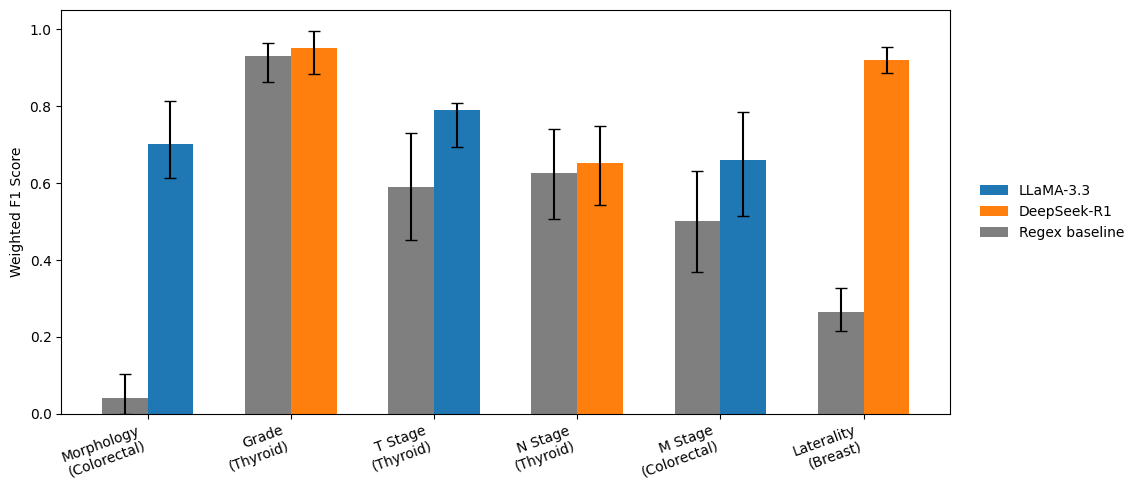

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------
# Data
# ------------------------------
fields = [
    "Morphology\n(Colorectal)",
    "Grade\n(Thyroid)",
    "T Stage\n(Thyroid)",
    "N Stage\n(Thyroid)",
    "M Stage\n(Colorectal)",
    "Laterality\n(Breast)"
]

regex_mean = np.array([0.0426, 0.9295, 0.5897, 0.6272, 0.5006, 0.2638])
regex_low  = np.array([0.0000, 0.8625, 0.4531, 0.5076, 0.3688, 0.2163])
regex_high = np.array([0.1044, 0.9655, 0.7309, 0.7395, 0.6315, 0.3260])

best_mean = np.array([0.7026, 0.9513, 0.7898, 0.6510, 0.6592, 0.9188])
best_low  = np.array([0.6141, 0.8824, 0.6936, 0.5436, 0.5137, 0.8852])
best_high = np.array([0.8139, 0.9963, 0.8071, 0.7481, 0.7852, 0.9543])

best_model = [
    "LLaMA-3.3",
    "DeepSeek-R1",
    "LLaMA-3.3",
    "DeepSeek-R1",
    "LLaMA-3.3",
    "DeepSeek-R1"
]

# Colors
color_regex    = "#7f7f7f"
color_llama    = "#1f77b4"
color_deepseek = "#ff7f0e"

best_colors = [
    color_llama if m == "LLaMA-3.3" else color_deepseek
    for m in best_model
]

# Error bars
regex_err = np.vstack([regex_mean - regex_low, regex_high - regex_mean])
best_err  = np.vstack([best_mean - best_low, best_high - best_mean])

# ------------------------------
# Plot
# ------------------------------
x = np.arange(len(fields))
width = 0.32

plt.figure(figsize=(11.5, 5))

plt.bar(x - width/2, regex_mean, width,
        yerr=regex_err, capsize=4,
        color=color_regex)

plt.bar(x + width/2, best_mean, width,
        yerr=best_err, capsize=4,
        color=best_colors)

plt.xticks(x, fields, rotation=20, ha="right")
plt.ylabel("Weighted F1 Score")
plt.ylim(0, 1.05)

# Legend outside
legend_patches = [
    Patch(facecolor=color_llama,    label="LLaMA-3.3"),
    Patch(facecolor=color_deepseek, label="DeepSeek-R1"),
    Patch(facecolor=color_regex,    label="Regex baseline")
]

plt.legend(
    handles=legend_patches,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()

# ------------------------------
# SAVE HIGH-QUALITY FIGURE
# ------------------------------
plt.savefig(
    "Figure_5_Best_LLM_vs_Regex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
